# MIVA-KNIGHT — Pipeline D: CREMA-D Audio-Visual Multimodal Emotion Recognition
## Cross-Modal InfoNCE → SupCon Refinement | Wav2Vec + ResNet-50 | 7,442 .mp4 Clips

---

### What This Notebook Does and Why

Pipeline D is the **final and most data-rich** of the four MIVA-KNIGHT pipelines.
It trains audio–visual emotion recognition on the CREMA-D dataset:
7,442 short video clips from 91 actors expressing 6 emotion categories.

**Key design decisions:**
- **Two frozen backbones** (Wav2Vec 2.0 for audio, ResNet-50 for video) extract
  features once and cache them — projection heads train on top of cached vectors.
- **Two-stage contrastive training:** InfoNCE aligns audio↔video embeddings
  across modalities first; SupCon then sharpens emotion-class cluster boundaries.
- **Warm-start from Pipeline C:** AudioProjection weights from RAVDESS training
  (6/8 emotions @ 59%) are inherited if available, giving Pipeline D a head start.

---

### Full System Architecture

```
╔══════════════════════════════════════════════════════════════════════════════╗
║          Pipeline D — CREMA-D Audio-Visual Training                         ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  CREMA-D .mp4 clip  (e.g. 1001_DFA_ANG_XX.mp4)                             ║
║       │                                                                      ║
║       ├─── AUDIO BRANCH ─────────────────────────────────────────────────  ║
║       │    Extract audio track → mono 16 kHz waveform                       ║
║       │         │                                                            ║
║       │    ┌────────────────────────────────────────┐                       ║
║       │    │  Wav2Vec 2.0   (FROZEN, 94 M params)   │                       ║
║       │    │  facebook/wav2vec2-base-960h             │  ← cached once      ║
║       │    │  CNN + 12-layer Transformer              │                       ║
║       │    │  → mean-pool → e_wav ∈ ℝ⁷⁶⁸            │                       ║
║       │    └────────────────────────────────────────┘                       ║
║       │         │  768d                                                      ║
║       │    ┌────────────────────────────────────────┐                       ║
║       │    │  AudioProjection   (TRAINS, ~790 K)    │                       ║
║       │    │  Linear(768→768) → GELU → LN(768)      │                       ║
║       │    │  → Linear(768→512) → LN(512) → L2-norm │                       ║
║       │    └────────────────────────────────────────┘                       ║
║       │         │  512d  ê_audio ∈ 𝕊⁵¹¹                                   ║
║       │                  ↕  InfoNCE loss (same clip = positive pair)         ║
║       │         │  512d  ê_video ∈ 𝕊⁵¹¹                                   ║
║       ├─── VIDEO BRANCH ─────────────────────────────────────────────────  ║
║       │    Extract middle frame → RGB 224×224                                ║
║       │         │                                                            ║
║       │    ┌────────────────────────────────────────┐                       ║
║       │    │  ResNet-50   (FROZEN, 23 M params)     │                       ║
║       │    │  ImageNet pretrained                    │  ← cached once       ║
║       │    │  pool5 features → f_img ∈ ℝ²⁰⁴⁸      │                       ║
║       │    └────────────────────────────────────────┘                       ║
║       │         │  2048d                                                     ║
║       │    ┌────────────────────────────────────────┐                       ║
║       │    │  VideoFrameProjection  (TRAINS, ~2.6M) │                       ║
║       │    │  Linear(2048→1024) → GELU → LN(1024)  │                       ║
║       │    │  → Linear(1024→512) → LN(512) → L2-norm│                      ║
║       │    └────────────────────────────────────────┘                       ║
║       │         │  512d  ê_video ∈ 𝕊⁵¹¹                                   ║
║                                                                              ║
║  ┌─────────────────────────────────────────────────────────────────────┐   ║
║  │  Stage 1 — Cross-Modal InfoNCE (13 epochs)                          │   ║
║  │  Loss: align ê_audio ↔ ê_video for same clip                        │   ║
║  │  Positive: (audio_i, video_i)  same clip                            │   ║
║  │  Negative: (audio_i, video_j)  different clips, j≠i                 │   ║
║  └─────────────────────────────────────────────────────────────────────┘   ║
║  ┌─────────────────────────────────────────────────────────────────────┐   ║
║  │  Stage 2 — SupCon Refinement (10 epochs, audio-only)                │   ║
║  │  Loss: sharpen emotion cluster boundaries using CREMA-D labels       │   ║
║  │  LR: 1e-5 (very conservative — preserves InfoNCE geometry)          │   ║
║  └─────────────────────────────────────────────────────────────────────┘   ║
║                                                                              ║
║  Outputs:  emotion_centroids_cremad.pt  [6 × 512]                          ║
║            audio_projection_cremad.pth                                      ║
║            video_frame_projection.pth                                       ║
╚══════════════════════════════════════════════════════════════════════════════╝
```

### CREMA-D Dataset Overview

| Property | Value |
|---|---|
| Full name | Crowd-sourced Emotional Multimodal Actors Dataset |
| Clips | 7,442 short `.mp4` files |
| Actors | 91 (diverse age, gender, ethnicity) |
| Emotions | 6: angry, disgust, fearful, happy, neutral, sad |
| Duration | ~3–5 s per clip |
| Audio | Embedded in `.mp4`, extracted as 16 kHz mono |
| Video | RGB frames, middle frame used as visual anchor |

### 4-Pipeline Context

| Pipeline | Dataset | Modalities | Loss | Status |
|---|---|---|---|---|
| A — COCO | COCO val2017 | Text + Image | InfoNCE | ✅ Month 1 |
| B — ROCO | ROCO radiology | Text + Image | InfoNCE | ✅ Month 4 |
| C — RAVDESS | 1,440 clips, 8 emotions | Audio | SupCon | ✅ Done |
| **D — CREMA-D** | **7,442 clips, 6 emotions** | **Audio + Video** | **InfoNCE → SupCon** | 🔄 **Now** |

**Run every cell top to bottom. Do not skip.**


## Cell 1: Install Dependencies

### Package Inventory

| Package | Role in Pipeline D | New vs Pipeline C? |
|---|---|---|
| `transformers` | Wav2Vec 2.0 model + processor (HuggingFace Hub) | No |
| `torchaudio` | Audio loading from `.mp4`, resampling to 16 kHz | No |
| `torchvision` | ResNet-50 backbone + ImageNet preprocessing transforms | **YES** — video modality |
| `soundfile` | Low-level `.wav` reading (librosa/torchaudio backend) | No |
| `librosa` | Audio loading fallback | No |
| `opencv-python` (`cv2`) | Middle-frame extraction from `.mp4` video files | **YES** — video modality |
| `datasets` | Optional HuggingFace dataset download fallback | No |

### Why OpenCV for Frame Extraction?

`cv2.VideoCapture` provides direct random-access seeking into `.mp4` files:

```python
cap.set(cv2.CAP_PROP_POS_FRAMES, total_frames // 2)  # seek to middle frame
ret, frame = cap.read()                               # decode one frame
```

This is more efficient than decoding the entire video stream (as PyTorch's
`torchvision.io.read_video` would do). For 7,442 clips, middle-frame extraction
with OpenCV takes ~5 minutes vs ~45 minutes with full video decoding.

> **Simple explanation:** This cell installs every tool Pipeline D needs.
> The two new additions compared to Pipeline C are `torchvision` (for the
> ResNet-50 image model) and `opencv-python` (for opening video files and
> jumping directly to the middle frame without watching the whole clip).


In [1]:
!pip install -q datasets transformers torchaudio torchvision soundfile librosa opencv-python
print("Packages installed")

Packages installed


## Cell 2: Imports & Reproducibility Setup

### Deterministic Seeding

**Theorem (Reproducible Training):** Setting `torch.manual_seed(42)` and
`np.random.seed(42)` before any stochastic operation guarantees bit-identical
results across runs on the same hardware, assuming no non-deterministic CUDA
kernels are triggered.

Both seeds are set to 42 for consistency with all MIVA-KNIGHT notebooks.

### OpenCV Optional Import

```python
try:
    import cv2
    CV2_AVAILABLE = True
except ImportError:
    CV2_AVAILABLE = False
```

OpenCV is wrapped in a try-except so that if it fails to import (e.g., on
some Colab configurations), the notebook falls back to a grey placeholder
frame rather than crashing. All downstream code checks `CV2_AVAILABLE`
before attempting video operations.

### Key Namespaces for Pipeline D

| Import | Role |
|---|---|
| `torch.nn`, `torch.nn.functional` | AudioProjection, VideoFrameProjection layers |
| `torchaudio` | `.mp4` audio track extraction, 16 kHz resampling |
| `torchvision.models`, `ResNet50_Weights` | Frozen ResNet-50 backbone for video frames |
| `torchvision.transforms` | ImageNet normalisation pipeline for frames |
| `transformers.Wav2Vec2Model/Processor` | Frozen Wav2Vec 2.0 audio encoder |
| `cv2` | Random-access frame seeking in `.mp4` files |
| `PIL.Image` | Frame format conversion (BGR→RGB→PIL→Tensor) |
| `collections.defaultdict, Counter` | Centroid aggregation, emotion counting |

> **Simple explanation:** This cell imports all the specialist tools. Because
> Pipeline D processes both audio and video, it needs more imports than
> Pipeline C (audio-only). The optional OpenCV import is a safety net —
> if the video library is unavailable, the notebook uses a grey image
> placeholder instead of crashing.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
import json, os, io, time, warnings
from tqdm.auto import tqdm
from collections import defaultdict, Counter

import torchaudio
import torchvision.models as models
from torchvision import transforms
from torchvision.models import ResNet50_Weights
from transformers import Wav2Vec2Model, Wav2Vec2Processor
from PIL import Image
import soundfile as sf

try:
    import cv2
    CV2_AVAILABLE = True
except ImportError:
    CV2_AVAILABLE = False

warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {device}')
if device == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'PyTorch : {torch.__version__}')
print("All imports complete")

Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB
PyTorch : 2.10.0+cu128
All imports complete


## Cell 3: Mount Drive, Set Paths & Training Configuration

### PyTorch 2.6 Compatibility Patch

PyTorch ≥ 2.6 changed the default of `torch.load` to `weights_only=True`,
blocking pickled Python objects (optimizer state dicts, loss lists, etc.).
The patch monkeypatches `torch.load` before any checkpoint is read:

```python
def _patched_load(f, *args, **kwargs):
    kwargs.setdefault('weights_only', False)   # restore pre-2.6 behaviour
    return _orig_load(f, *args, **kwargs)
torch.load = _patched_load
```

**This must run before any `torch.load()` call in the session.**

### Directory Structure on Drive

```
Project Base/
├── Data/
│   ├── Crema-d/                    ← CREMA_DIR
│   │   ├── Actor_1001/
│   │   │   ├── 1001_DFA_ANG_XX.mp4
│   │   │   └── ...  (~82 clips)
│   │   ├── Actor_1002/ ... Actor_1091/
│   │   └── (91 actor folders, 7,442 total .mp4 files)
│   └── crema_embeddings_cache/
│       └── crema_cache.pt          ← CACHE_FILE  (built once, ~380 MB)
│
└── models/
    ├── miva_knight_pipelineC/
    │   └── audio_projection.pth    ← warm-start source (optional)
    └── miva_knight_pipelineD/      ← PIPELINE_D_DIR
        ├── checkpoint_pipelineD_latest.pth
        ├── audio_projection_cremad.pth
        ├── video_frame_projection.pth
        ├── emotion_centroids_cremad.pt
        └── config.json
```

### Training Hyperparameter Rationale

| Hyperparameter | Value | Rationale |
|---|---|---|
| `EMBED_DIM` | 512 | Shared across all 4 MIVA-KNIGHT pipelines |
| `WAV2VEC_DIM` | 768 | Correct Wav2Vec 2.0 base output (bug-fixed from Month 2's 512) |
| `RESNET_DIM` | 2048 | ResNet-50 pool5 feature dimension |
| `NUM_EPOCHS` | 13 | ~3 min/epoch × 13 = ~40 min; fits one Colab session |
| `BATCH_SIZE` | 32 | 32 clips → 32 audio-video pairs per InfoNCE step |
| `TEMPERATURE` | 0.07 | Consistent with Pipelines A–C; sharp softmax |
| `LEARNING_RATE` | 1e-4 | Default; reduced to 5e-5 if warm-starting from Pipeline C |
| `WEIGHT_DECAY` | 0.01 | AdamW decoupled L2 regularisation |

### Auto-Detect Project Base

The cell tries multiple candidate paths (with/without trailing space, shortcut
targets) to locate the project folder on Drive. This makes the notebook robust
to different Colab mounting configurations without requiring manual path editing.

> **Simple explanation:** This cell maps out where every file lives on your
> Google Drive, applies a one-line fix for a PyTorch version incompatibility,
> and records all the training settings in named constants. The auto-detection
> logic means you don't need to manually edit the path even if Drive mounts
> slightly differently on different Colab sessions.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# PyTorch 2.6 patch
import torch as _torch
_orig_load = _torch.load
def _patched_load(f, *args, **kwargs):
    kwargs.setdefault('weights_only', False)
    return _orig_load(f, *args, **kwargs)
_torch.load = _patched_load
print("PyTorch 2.6 patch applied")

# Auto-detect project base
POSSIBLE_BASES = [
    '/content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project ',
    '/content/drive/MyDrive/Oluwakayode Soyinka IT 581 Project',
]
shortcut_root = '/content/drive/.shortcut-targets-by-id'
if os.path.exists(shortcut_root):
    for sid in os.listdir(shortcut_root):
        sp = os.path.join(shortcut_root, sid)
        if os.path.isdir(sp):
            for folder in os.listdir(sp):
                if 'soyinka' in folder.lower() or '581' in folder.lower():
                    POSSIBLE_BASES.append(os.path.join(sp, folder))

PROJECT_BASE = None
for path in POSSIBLE_BASES:
    if os.path.exists(path) and os.path.exists(os.path.join(path, 'models')):
        PROJECT_BASE = path
        break

if PROJECT_BASE is None:
    raise RuntimeError('Project folder not found.')
print(f'Project base: {PROJECT_BASE}')

CREMA_DIR       = os.path.join(PROJECT_BASE, 'Data', 'Crema-d')
CACHE_DIR       = os.path.join(PROJECT_BASE, 'Data', 'crema_embeddings_cache')
CACHE_FILE      = os.path.join(CACHE_DIR, 'crema_cache.pt')
PIPELINE_D_DIR  = os.path.join(PROJECT_BASE, 'models', 'miva_knight_pipelineD')
PIPELINE_C_DIR  = os.path.join(PROJECT_BASE, 'models', 'miva_knight_pipelineC')
CHECKPOINT      = os.path.join(PIPELINE_D_DIR, 'checkpoint_pipelineD_latest.pth')

for d in [CACHE_DIR, PIPELINE_D_DIR]:
    os.makedirs(d, exist_ok=True)

# Config
EMBED_DIM     = 512
WAV2VEC_DIM   = 768
RESNET_DIM    = 2048
NUM_EPOCHS    = 13
BATCH_SIZE    = 32
TEMPERATURE   = 0.07
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 0.01

assert os.path.exists(CREMA_DIR), f'Crema-d not found at: {CREMA_DIR}'
actor_dirs = sorted([d for d in os.listdir(CREMA_DIR)
                     if os.path.isdir(os.path.join(CREMA_DIR, d))])
total_mp4 = sum(
    len([f for f in os.listdir(os.path.join(CREMA_DIR, a)) if f.endswith('.mp4')])
    for a in actor_dirs)
print(f'CREMA-D : {len(actor_dirs)} actors | {total_mp4:,} .mp4 files')
print(f'Epochs  : {NUM_EPOCHS} | Batch: {BATCH_SIZE} | LR: {LEARNING_RATE}')
print(f'Cache   : {CACHE_FILE}')

Mounted at /content/drive
PyTorch 2.6 patch applied
Project base: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project 
CREMA-D : 91 actors | 7,442 .mp4 files
Epochs  : 13 | Batch: 32 | LR: 0.0001
Cache   : /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /Data/crema_embeddings_cache/crema_cache.pt


## Cell 4: Filename Parser, Emotion Mapping & Middle-Frame Extraction

### CREMA-D Filename Encoding

Every CREMA-D clip encodes actor, sentence type, and emotion in its filename:

```
1001  _  DFA  _  ANG  _  XX  .mp4
 │        │       │       │
 │        │       │       └── Level (XX = unspecified intensity)
 │        │       └────────── Emotion code  (3-letter abbreviation)
 │        └────────────────── Sentence code (IEO, TIE, IOM, IWW, TAI, MTI, IWL, ITH, DFA, ITS, TSI, WSI)
 └─────────────────────────── Actor ID (1001–1091, i.e., 91 actors)
```

**Emotion code → label mapping (6 classes):**

| Code | Emotion | Integer Label |
|---|---|---|
| `ANG` | angry | 0 |
| `DIS` | disgust | 1 |
| `FEA` | fearful | 2 |
| `HAP` | happy | 3 |
| `NEU` | neutral | 4 |
| `SAD` | sad | 5 |

### Filename Parser Algorithm

```
Algorithm: PARSE_CREMA_FILENAME(filename)
──────────────────────────────────────────────────────────────
Input:  filename (string, e.g. "1001_DFA_ANG_XX.mp4")
Output: {actor_id, sentence, emotion, stem} or None

1. stem  ← strip extension from basename
2. parts ← stem.split('_')
3. IF len(parts) ∉ {4, 5}: RETURN None
   (handles both 4-part and 5-part naming conventions)
4. actor_str ← parts[0];  sentence ← parts[1];  emotion_code ← parts[2]
5. IF emotion_code ∉ CREMA_EMOTION_MAP: RETURN None
6. actor_id ← int(actor_str)  (fails → RETURN None)
7. RETURN {
       actor_id: actor_id,
       sentence: sentence,
       emotion : CREMA_EMOTION_MAP[emotion_code],
       stem    : stem,
   }
──────────────────────────────────────────────────────────────
```

### Middle-Frame Extraction Algorithm

**Why the middle frame?** The middle frame of an acted emotional expression
typically captures the peak facial configuration (e.g., widest smile for
happy, most furrowed brow for angry) before the actor relaxes. Using a
single representative frame is computationally efficient and well-supported
by the facial action coding literature.

```
Algorithm: EXTRACT_MIDDLE_FRAME(mp4_path)
──────────────────────────────────────────────────────────────
Input:  mp4_path — path to .mp4 video file
Output: (frame_tensor [3,224,224], success_bool)

1. IF cv2 not available: RETURN (GRAY_FRAME, False)
2. cap ← cv2.VideoCapture(mp4_path)
3. IF NOT cap.isOpened():  RETURN (GRAY_FRAME, False)
4. total ← cap.get(CAP_PROP_FRAME_COUNT)
5. IF total == 0: RETURN (GRAY_FRAME, False)
6. cap.set(CAP_PROP_POS_FRAMES, max(0, total // 2))  ← seek to middle
7. ret, frame ← cap.read()
8. cap.release()
9. IF NOT ret:  RETURN (GRAY_FRAME, False)
10. rgb ← cv2.cvtColor(frame, COLOR_BGR2RGB)   ← OpenCV is BGR, PIL needs RGB
11. pil_img ← Image.fromarray(rgb)
12. tensor  ← FRAME_TRANSFORM(pil_img)         ← Resize(224) → ToTensor → Normalize
13. RETURN (tensor, True)
──────────────────────────────────────────────────────────────
```

### ImageNet Normalisation Transform

$$\hat{x}_{c,h,w} = \frac{x_{c,h,w} - \mu_c}{\sigma_c},
\quad \boldsymbol{\mu} = [0.485, 0.456, 0.406],\;
\boldsymbol{\sigma} = [0.229, 0.224, 0.225]$$

These are the training-set statistics of ImageNet-1K. ResNet-50's batch
normalisation layers are calibrated to this input distribution — using
different statistics would shift pool5 activations out of distribution.

**Fallback `GRAY_FRAME`:** When OpenCV fails (corrupt file, missing codec),
a 224×224 grey image is used instead. The cache entry is marked
`has_video: False`, and the training mode falls back from cross-modal
InfoNCE to audio-only SupCon if fewer than 50% of clips have valid frames.

> **Simple explanation:** This cell teaches the notebook how to read CREMA-D
> filenames (like decoding a barcode — each section of the name carries specific
> information about the actor and emotion), and how to open a video file and
> jump directly to its middle frame without watching the whole thing.
> When a video file is broken or unreadable, a plain grey image is used as a
> safe placeholder so training never crashes.


In [4]:
CREMA_EMOTION_MAP = {
    'ANG': 'angry', 'DIS': 'disgust', 'FEA': 'fearful',
    'HAP': 'happy', 'NEU': 'neutral', 'SAD': 'sad',
}
CREMA_EMOTIONS_6       = ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad']
CREMA_EMOTION_TO_LABEL = {e: i for i, e in enumerate(CREMA_EMOTIONS_6)}
CREMA_LABEL_TO_EMOTION = {i: e for i, e in enumerate(CREMA_EMOTIONS_6)}

FRAME_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])
GRAY_FRAME = FRAME_TRANSFORM(Image.new('RGB', (224, 224), 'gray'))


def parse_crema_filename(filename):
    # Handles both 4-part (1001_DFA_ANG_XX.mp4) and
    # 5-part (1001_DFA_ANG_XX_01.mp4) formats
    stem  = os.path.splitext(os.path.basename(filename))[0]
    parts = stem.split('_')
    if len(parts) not in (4, 5):
        return None
    actor_str, sentence, emotion_code = parts[0], parts[1], parts[2]
    if emotion_code not in CREMA_EMOTION_MAP:
        return None
    try:
        actor_id = int(actor_str)
    except ValueError:
        return None
    return {
        'actor_id': actor_id,
        'sentence': sentence,
        'emotion' : CREMA_EMOTION_MAP[emotion_code],
        'stem'    : stem,
    }


def extract_middle_frame(mp4_path):
    if not CV2_AVAILABLE:
        return GRAY_FRAME.clone(), False
    try:
        cap   = cv2.VideoCapture(mp4_path)
        if not cap.isOpened():
            return GRAY_FRAME.clone(), False
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total == 0:
            cap.release()
            return GRAY_FRAME.clone(), False
        cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, total // 2))
        ret, frame = cap.read()
        cap.release()
        if not ret or frame is None:
            return GRAY_FRAME.clone(), False
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        return FRAME_TRANSFORM(Image.fromarray(rgb)), True
    except Exception:
        return GRAY_FRAME.clone(), False


# Count all valid clips
all_mp4 = []
emotion_counts = Counter()
for actor_dir in actor_dirs:
    actor_path = os.path.join(CREMA_DIR, actor_dir)
    for f in sorted(os.listdir(actor_path)):
        if not f.endswith('.mp4'):
            continue
        meta = parse_crema_filename(f)
        if meta:
            all_mp4.append((os.path.join(actor_path, f), meta))
            emotion_counts[meta['emotion']] += 1

print(f'Valid .mp4 files: {len(all_mp4):,}')
print(f'\nEmotion distribution:')
for emotion in CREMA_EMOTIONS_6:
    ct  = emotion_counts.get(emotion, 0)
    bar = chr(9608) * (ct // 80)
    print(f'  {emotion:<10}: {ct:5d}  {bar}')

Valid .mp4 files: 7,442

Emotion distribution:
  angry     :  1271  ███████████████
  disgust   :  1271  ███████████████
  fearful   :  1271  ███████████████
  happy     :  1271  ███████████████
  neutral   :  1087  █████████████
  sad       :  1271  ███████████████


## Cell 5: Wav2Vec 2.0 Encoder (Frozen Backbone)

### Role in Pipeline D

The `Wav2VecEncoder` is used **only once** — during the one-time cache
extraction in Cell 6.  After the 768d embeddings are saved to Drive,
Wav2Vec is deleted from VRAM and is never loaded again during training.
The projection heads train on the pre-computed cached vectors.

### Wav2Vec 2.0 Architecture

Wav2Vec 2.0 (Baevski et al., 2020, NeurIPS) learns speech representations
by solving a contrastive task on masked frames of raw waveform:

```
Raw waveform  [1, T]     T = samples at 16 kHz
       │
       ▼  CNN Feature Encoder (7 temporal convolution layers)
   [1, T/320, 512]       one 512-d frame per 20 ms of audio
       │
       ▼  Transformer Context Network (12 layers, d_model=768)
   [1, T', 768]          contextualised frame-level hidden states
       │
       ▼  Mean-pool over time axis T'
   [1, 768]              sentence-level audio representation
```

**Why mean-pool over time?**

$$e_{\text{wav}} = \frac{1}{T'}\sum_{t=1}^{T'} h_t^{(12)} \in \mathbb{R}^{768}$$

For a 3-second clip at 16 kHz: $T = 48{,}000$ samples,
$T' \approx 150$ frames.  Mean-pooling captures the average emotional
quality across the entire utterance — appropriate because emotion is a
global property of the speech act, not localised to a single frame.

### Audio Preprocessing Pipeline

```
mp4_path
    │
    ▼  torchaudio.load()  →  waveform [channels, T], sample_rate
    │
    ▼  IF sr ≠ 16000: resample(waveform, sr, 16000)
    │
    ▼  IF stereo: mean(channels, dim=0, keepdim=True)  →  mono [1, T]
    │
    ▼  squeeze(0).numpy()  →  [T]  numpy float32
    │
    ▼  Wav2Vec2Processor  →  normalise, return input_values [1, T]
    │
    ▼  Wav2Vec2Model.forward()  →  last_hidden_state [1, T', 768]
    │
    ▼  mean(dim=1)  →  [1, 768]
    │
    ▼  .cpu()  →  [1, 768]  on CPU
```

### Why Freeze Wav2Vec?

**Theorem (Transfer Learning Efficiency):** Freezing Wav2Vec 2.0's 94 M
parameters provides three simultaneous benefits:

1. **VRAM saving:** 94 M float32 params ≈ 360 MB; freed after caching gives
   ~12 GB headroom for training on Colab T4.
2. **No catastrophic forgetting:** Fine-tuning on 7,442 clips would overwrite
   960-hour LibriSpeech phonetic representations.
3. **Speed:** Backpropagation through a 12-layer Transformer is skipped
   every batch — training runs ~10× faster.

> **Simple explanation:** Wav2Vec is a specialist listener trained on 960 hours
> of speech. We borrow its ears (frozen) but only run it once on all 7,442
> clips, saving the 768-number fingerprints to Drive. During the actual
> training that follows, we never touch Wav2Vec again — we train only
> the small translator (AudioProjection) that learns to arrange those
> fingerprints by emotion.


In [5]:
class Wav2VecEncoder(nn.Module):
    def __init__(self, model_name='facebook/wav2vec2-base-960h'):
        super().__init__()
        print(f'  Loading {model_name}...')
        self.processor = Wav2Vec2Processor.from_pretrained(model_name)
        self.model     = Wav2Vec2Model.from_pretrained(model_name)
        for p in self.model.parameters():
            p.requires_grad = False
        self.model.eval()
        print('  Wav2Vec 2.0 frozen (94M params, 0 trainable)')

    @torch.no_grad()
    def encode_file(self, wav_path):
        waveform, sr = torchaudio.load(wav_path)
        if sr != 16000:
            waveform = torchaudio.functional.resample(waveform, sr, 16000)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        wave_np = waveform.squeeze(0).numpy()
        inputs  = self.processor(
            wave_np, sampling_rate=16000,
            return_tensors='pt', padding=True
        )
        iv  = inputs.input_values.to(next(self.model.parameters()).device)
        out = self.model(iv)
        return out.last_hidden_state.mean(dim=1).cpu()   # [1, 768]


print("Wav2VecEncoder defined (used only for cache extraction)")

Wav2VecEncoder defined (used only for cache extraction)


## Cell 6: One-Time Feature Extraction & Caching

### Why Cache Instead of Encoding On-the-Fly?

**Lemma (Caching Speed-up):**
Each Wav2Vec forward pass on a 3-second clip takes $\approx 0.3$ s on GPU.
Without caching across 13 training epochs:

$$T_{\text{no-cache}} = 7{,}442 \times 13 \times 0.3\;\text{s} \approx 29{,}024\;\text{s} \approx \mathbf{8\;hours}$$

With one-time caching ($\approx 15$–20 min):

$$T_{\text{cached}} \approx 1{,}080\;\text{s} + 13 \times 30\;\text{s} \approx \mathbf{27\;min}$$

Speed-up: $\approx \mathbf{17\times}$.  Similarly for ResNet-50 frame encoding.

### Full Extraction Algorithm

```
Algorithm: EXTRACT_AND_CACHE()
──────────────────────────────────────────────────────────────────────
Input:  all_mp4  — list of (mp4_path, meta) tuples (7,442 entries)
        CACHE_FILE — Drive path for persistent storage

1. IF CACHE_FILE exists AND len(cache) > 100:
       cache ← torch.load(CACHE_FILE)
       assert cache[*]['audio_emb'].shape[0] == 768  ← dimension guard
       RETURN cache                      ← resume-safe shortcut

2. wav2vec ← Wav2VecEncoder().to(device)   ← load once

3. FOR each (mp4_path, meta) in all_mp4:
   a. audio_emb ← wav2vec.encode_file(mp4_path).squeeze(0)   [768]
      ON EXCEPTION: skipped += 1; continue

   b. frame_tensor, frame_ok ← extract_middle_frame(mp4_path) [3,224,224]

   c. cache[meta['stem']] = {
          'audio_emb'   : audio_emb,          [768]
          'frame_tensor': frame_tensor,        [3,224,224]
          'emotion'     : meta['emotion'],
          'label'       : CREMA_EMOTION_TO_LABEL[meta['emotion']],  0-5
          'actor_id'    : meta['actor_id'],
          'has_video'   : frame_ok,
      }

4. del wav2vec; torch.cuda.empty_cache()   ← free 360 MB VRAM

5. torch.save(cache, CACHE_FILE)

6. n_with_video ← count(has_video == True)
   CROSS_MODAL ← (n_with_video / len(cache)) >= 0.5
   ← if <50% clips have valid video, fall back to audio-only SupCon

7. RETURN cache
──────────────────────────────────────────────────────────────────────
Output: dict  stem → {audio_emb[768], frame_tensor[3,224,224],
               emotion, label, actor_id, has_video}
```

### Cache Entry Schema

```python
{
  '1001_DFA_ANG_XX': {
      'audio_emb'   : tensor([768]),         # Wav2Vec 2.0 mean-pool
      'frame_tensor': tensor([3, 224, 224]), # middle frame, ImageNet-norm
      'emotion'     : 'angry',
      'label'       : 0,                    # integer 0-5
      'actor_id'    : 1001,
      'has_video'   : True,
  },
  ...
}
```

### Training Mode Selection

After caching, the training mode is set automatically:

```
n_with_video / len(cache) ≥ 0.5?
         /           \
      YES              NO
       |                |
CROSS_MODAL = True   CROSS_MODAL = False
Cross-modal InfoNCE  Audio-only SupCon
(audio ↔ video)      (emotion labels)
```

In practice, CREMA-D's `.mp4` files are well-formed, so `CROSS_MODAL = True`
and cross-modal InfoNCE is used throughout Stage 1.

### VRAM Lifecycle

```
Cell 6 start:  Wav2Vec loaded   → +360 MB VRAM
Cell 6 end:    Wav2Vec deleted  → VRAM freed
Cell 12 start: AudioProjection  → +4 MB VRAM
               VideoProjection  → +10 MB VRAM
Training:      Cache on CPU (380 MB RAM), batches moved to GPU per step
```

> **Simple explanation:** This is the most time-consuming cell, but it runs
> only once. It opens every one of the 7,442 video files, extracts the audio
> fingerprint (768 numbers from Wav2Vec) and the middle video frame
> (a 3×224×224 image), and saves everything to a single file on Drive.
> Future runs skip all this work and load the saved file in seconds.
> After saving, Wav2Vec is deleted from GPU memory to make room for training.


In [6]:
def extract_and_cache():
    # Load existing cache
    if os.path.exists(CACHE_FILE):
        print(f'Cache found - loading...')
        cache = torch.load(CACHE_FILE, map_location='cpu')
        if len(cache) > 100:
            sample  = next(iter(cache.values()))
            adim    = sample['audio_emb'].shape[0]
            n_video = sum(1 for v in cache.values() if v.get('has_video', False))
            print(f'  {len(cache):,} entries | audio: {adim}d | with_video: {n_video}')
            assert adim == 768, f'Cache audio dim={adim}, expected 768. Delete {CACHE_FILE} and rerun.'
            return cache
        else:
            print(f'  Cache too small ({len(cache)}) - re-extracting')

    print(f'Extracting {len(all_mp4):,} clips (one-time ~15-20 min)...')
    wav2vec = Wav2VecEncoder().to(device)

    cache      = {}
    skipped    = 0
    video_ok   = 0
    emotion_ct = Counter()

    for mp4_path, meta in tqdm(all_mp4, desc='Extracting'):
        # Audio: Wav2Vec encode
        try:
            audio_emb = wav2vec.encode_file(mp4_path).squeeze(0)  # [768]
        except Exception:
            skipped += 1
            continue

        # Video: middle frame
        frame_tensor, frame_ok = extract_middle_frame(mp4_path)
        if frame_ok:
            video_ok += 1

        cache[meta['stem']] = {
            'audio_emb'   : audio_emb,
            'frame_tensor': frame_tensor,
            'emotion'     : meta['emotion'],
            'label'       : CREMA_EMOTION_TO_LABEL[meta['emotion']],
            'actor_id'    : meta['actor_id'],
            'has_video'   : frame_ok,
        }
        emotion_ct[meta['emotion']] += 1

    # Free Wav2Vec VRAM before training
    del wav2vec
    if device == 'cuda':
        torch.cuda.empty_cache()

    torch.save(cache, CACHE_FILE)
    print(f'\nCache saved: {CACHE_FILE}')
    print(f'  Total     : {len(cache):,}')
    print(f'  Skipped   : {skipped}')
    print(f'  Audio dim : 768d')
    print(f'  Video ok  : {video_ok:,} / {len(cache):,}')
    print(f'  Emotions  : {dict(sorted(emotion_ct.items()))}')
    return cache


crema_cache = extract_and_cache()

n_with_video = sum(1 for v in crema_cache.values() if v['has_video'])
CROSS_MODAL  = n_with_video / max(len(crema_cache), 1) >= 0.5
print(f'\nMode: {"cross-modal InfoNCE" if CROSS_MODAL else "audio-only SupCon"}')
print(f'  Video frames: {n_with_video:,} / {len(crema_cache):,}')

if device == 'cuda':
    torch.cuda.empty_cache()
    free, total = torch.cuda.mem_get_info()
    print(f'  VRAM free after cache load: {free/1e9:.1f} / {total/1e9:.1f} GB')

Extracting 7,442 clips (one-time ~15-20 min)...
  Loading facebook/wav2vec2-base-960h...


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Wav2Vec 2.0 frozen (94M params, 0 trainable)


Extracting:   0%|          | 0/7442 [00:00<?, ?it/s]


Cache saved: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /Data/crema_embeddings_cache/crema_cache.pt
  Total     : 7,442
  Skipped   : 0
  Audio dim : 768d
  Video ok  : 7,442 / 7,442
  Emotions  : {'angry': 1271, 'disgust': 1271, 'fearful': 1271, 'happy': 1271, 'neutral': 1087, 'sad': 1271}

Mode: cross-modal InfoNCE
  Video frames: 7,442 / 7,442
  VRAM free after cache load: 15.5 / 15.6 GB


## Cell 7: AudioProjection & VideoFrameProjection Architectures

### Design Philosophy: Symmetric Projection Heads

Both projection heads share the same architectural pattern — 2-layer MLP
with GELU activation, LayerNorm, and final L2-normalisation — so that their
outputs lie on the same unit hypersphere $\mathbb{S}^{511}$ and cosine similarity
is a valid cross-modal distance metric.

### AudioProjection — Formal Definition

Let $x \in \mathbb{R}^{768}$ be the Wav2Vec mean-pooled embedding:

$$f_\theta^{\text{audio}} : \mathbb{R}^{768} \to \mathbb{S}^{511}$$

$$f_\theta^{\text{audio}}(x) = \frac{g_\theta(x)}{\|g_\theta(x)\|_2}$$

$$g_\theta(x) = \text{LN}_{512}\!\left(W_2 \cdot \text{GELU}\!\left(\text{LN}_{768}(W_1 x + b_1)\right) + b_2\right)$$

where $W_1 \in \mathbb{R}^{768 \times 768}$, $W_2 \in \mathbb{R}^{512 \times 768}$.

**Parameter count:**

| Layer | Parameters |
|---|---|
| `Linear(768→768)` | $768^2 + 768 = 590{,}592$ |
| `LayerNorm(768)` | $2 \times 768 = 1{,}536$ |
| `Linear(768→512)` | $768 \times 512 + 512 = 393{,}728$ |
| `LayerNorm(512)` | $2 \times 512 = 1{,}024$ |
| **Total** | **$\approx$986,880** |

### VideoFrameProjection — Formal Definition

Let $I \in \mathbb{R}^{3 \times 224 \times 224}$ be the ImageNet-normalised
middle frame. ResNet-50 extracts pool5 features, then the projection maps to
the shared 512-d space:

$$f_\phi^{\text{video}} : \mathbb{R}^{3 \times 224 \times 224} \to \mathbb{S}^{511}$$

$$f_\phi^{\text{video}}(I) = \text{L2-norm}\!\left(\text{LN}_{512}\!\left(W_4 \cdot \text{GELU}\!\left(\text{LN}_{1024}(W_3 \cdot \text{ResNet50}(I) + b_3)\right) + b_4\right)\right)$$

where $W_3 \in \mathbb{R}^{1024 \times 2048}$, $W_4 \in \mathbb{R}^{512 \times 1024}$.

```
Frame [3, 224, 224]
    │
    ▼  ResNet-50 backbone (FROZEN, 23 M params)
       Conv → BN → ReLU → [Layer1..4] → GlobalAvgPool
    │
    ▼  [2048]  (pool5 features)
    │
    ▼  Linear(2048 → 1024) + GELU + LayerNorm(1024)
    │
    ▼  Linear(1024 → 512) + LayerNorm(512)
    │
    ▼  L2-normalise
    │
    ▼  ê_video ∈ 𝕊⁵¹¹
```

**Trainable parameter count:**

| Layer | Parameters |
|---|---|
| `Linear(2048→1024)` | $2048 \times 1024 + 1024 = 2{,}098{,}176$ |
| `LayerNorm(1024)` | $2{,}048$ |
| `Linear(1024→512)` | $1024 \times 512 + 512 = 524{,}800$ |
| `LayerNorm(512)` | $1{,}024$ |
| **Trainable total** | **$\approx$2,627,048** |
| ResNet-50 backbone | $\approx$23.5 M (frozen) |

### Why Freeze the ResNet-50 Backbone During Video Forward Pass?

Unlike Pipeline A/B where ResNet features were pre-cached separately,
here the `VideoFrameProjection.forward()` runs the ResNet backbone
**inside** `torch.no_grad()` every batch. The backbone is frozen (no grad
computed), but the raw frame tensors are loaded from the cache and fed
through ResNet to get 2048d features on-the-fly.

**Rationale:** The 2048d ResNet features are too large to cache (7442 × 2048 × 4
bytes ≈ 60 MB additional per epoch) when the frames [3,224,224] are already
cached (7442 × 3 × 224 × 224 × 4 ≈ 450 MB). Running the frozen ResNet on
cached frames per batch is a memory–speed trade-off that keeps total cache
size manageable at ~380 MB.

**Lemma (Unit Sphere Alignment):** Since both $\hat{e}_{\text{audio}}$
and $\hat{e}_{\text{video}}$ are L2-normalised to $\mathbb{S}^{511}$:
$$\cos(\hat{e}_{\text{audio}}, \hat{e}_{\text{video}}) = \hat{e}_{\text{audio}} \cdot \hat{e}_{\text{video}} \in [-1, +1]$$
The inner product equals cosine similarity — the natural metric for InfoNCE.

> **Simple explanation:** AudioProjection is a small translator that converts
> Wav2Vec's 768-number audio fingerprint into a 512-number direction on a
> sphere. VideoFrameProjection does the same for ResNet's 2048-number image
> fingerprint. After training, the audio and video fingerprints of the same
> clip should point in the same direction on the sphere — that is the goal
> of cross-modal InfoNCE. Both heads are small (< 3 M params) compared to
> the frozen backbones (117 M total), so they train very quickly.


In [7]:
class AudioProjection(nn.Module):
    def __init__(self, wav2vec_dim=768, embed_dim=512):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(wav2vec_dim, wav2vec_dim),
            nn.GELU(),
            nn.LayerNorm(wav2vec_dim),
            nn.Linear(wav2vec_dim, embed_dim),
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x):
        return F.normalize(self.norm(self.proj(x)), p=2, dim=1)


class VideoFrameProjection(nn.Module):
    def __init__(self, embed_dim=512, freeze_backbone=True):
        super().__init__()
        resnet = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
        self.proj = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.GELU(),
            nn.LayerNorm(1024),
            nn.Linear(1024, embed_dim),
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, images):
        # images: [B, 3, 224, 224] cached frames
        with torch.no_grad():
            feat = self.backbone(images).flatten(1)  # [B, 2048]
        return F.normalize(self.norm(self.proj(feat)), p=2, dim=1)


n_audio = sum(p.numel() for p in AudioProjection().parameters())
_vp     = VideoFrameProjection()
n_video = sum(p.numel() for p in _vp.parameters() if p.requires_grad)
del _vp
print(f'AudioProjection      : {n_audio:,} params  (768->512)')
print(f'VideoFrameProjection : {n_video:,} trainable  (2048->512)')
print(f'ResNet-50 backbone   : ~23M frozen (not counted)')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 170MB/s]


AudioProjection      : 986,880 params  (768->512)
VideoFrameProjection : 2,626,048 trainable  (2048->512)
ResNet-50 backbone   : ~23M frozen (not counted)


## Cell 8: CREMADDataset & DataLoader

### Dataset Design

`CREMADDataset` wraps the flat cache dictionary into a PyTorch `Dataset`
that returns three items per sample:

| Return field | Shape | Type | Description |
|---|---|---|---|
| `audio_emb` | `[768]` | float32 | Pre-computed Wav2Vec embedding |
| `frame_tensor` | `[3, 224, 224]` | float32 | Pre-computed ImageNet-normalised frame |
| `label` | scalar | int64 | Emotion class index 0–5 |

```
Algorithm: CREMADDataset.__init__(cache)
──────────────────────────────────────────────────────
FOR each (stem, data) in cache.items():
    samples.append({
        audio_emb   : data['audio_emb'],          [768]
        frame_tensor: data['frame_tensor'],        [3,224,224]
        label       : data['label'],               0-5
        emotion     : data['emotion'],             string
        has_video   : data['has_video'],           bool
    })
    emotion_cts[data['emotion']] += 1
──────────────────────────────────────────────────────
__getitem__(idx):
    RETURN (audio_emb[768], frame_tensor[3,224,224], label_int)
```

### Custom `collate_fn`

The default PyTorch collate function cannot efficiently stack a mixed list
of dicts. A custom `collate_fn` pre-stacks the three fields:

```python
def collate_fn(batch):
    audio  = torch.stack([b[0] for b in batch])   # [B, 768]
    frames = torch.stack([b[1] for b in batch])   # [B, 3, 224, 224]
    labels = torch.tensor([b[2] for b in batch])  # [B]
    return audio, frames, labels
```

### DataLoader Configuration

| Parameter | Value | Rationale |
|---|---|---|
| `batch_size` | 32 | Larger than Pipeline C's 16 — more negatives per InfoNCE step |
| `shuffle` | True | Ensures IID mini-batches; breaks actor-ordering bias |
| `num_workers` | 0 | Colab multiprocessing compatibility |
| `pin_memory` | True (GPU) | Faster CPU→GPU transfer for `audio` and `frame` tensors |
| `drop_last` | True | Prevents partial batches that reduce InfoNCE negative count |
| `collate_fn` | custom | Efficient stacking of pre-computed tensors |

### Expected Batches per Epoch

$$\text{num\_batches} = \left\lfloor \frac{N}{B} \right\rfloor = \left\lfloor \frac{7{,}442}{32} \right\rfloor = 232$$

With `drop_last=True`, the last partial batch (< 32 samples) is discarded,
giving exactly 232 batches per epoch — each containing 32 audio-frame pairs.

**Lemma (Negative Count for InfoNCE):** With batch size $B = 32$, each anchor
has $B - 1 = 31$ negatives in the InfoNCE denominator. The random baseline is:
$$\mathcal{L}_{\text{InfoNCE}}^{\text{random}} = \log(B) = \log(32) \approx 3.47$$

> **Simple explanation:** The Dataset wraps the cache file into an iterable
> list of (audio fingerprint, video frame, emotion label) triplets.
> The DataLoader is like a shuffled card dealer — it draws 32 triplets at
> a time in random order, making sure each training step sees a different
> mixture of emotions. Using batches of 32 instead of 16 means the InfoNCE
> loss has more "wrong answer" candidates per clip, making the learning task
> harder and the resulting representations more discriminative.


In [8]:
class CREMADDataset(Dataset):
    def __init__(self, cache):
        self.samples = []
        emotion_cts  = Counter()
        for stem, data in cache.items():
            self.samples.append({
                'audio_emb'   : data['audio_emb'],
                'frame_tensor': data['frame_tensor'],
                'label'       : data['label'],
                'emotion'     : data['emotion'],
                'has_video'   : data['has_video'],
            })
            emotion_cts[data['emotion']] += 1
        n_video = sum(1 for s in self.samples if s['has_video'])
        frac    = n_video / max(len(self.samples), 1)
        print(f'CREMADDataset: {len(self.samples):,} samples')
        print(f'  Video frames : {n_video:,} ({frac*100:.1f}%)')
        print(f'  Emotion distribution:')
        for emotion in CREMA_EMOTIONS_6:
            ct  = emotion_cts.get(emotion, 0)
            bar = chr(9608) * (ct // 100)
            print(f'    {emotion:<10}: {ct:5d}  {bar}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        return s['audio_emb'], s['frame_tensor'], s['label']


def collate_fn(batch):
    audio  = torch.stack([b[0] for b in batch])         # [B, 768]
    frames = torch.stack([b[1] for b in batch])         # [B, 3, 224, 224]
    labels = torch.tensor([b[2] for b in batch])        # [B]
    return audio, frames, labels


crema_dataset = CREMADDataset(crema_cache)

audio_loader = DataLoader(
    crema_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 0,
    pin_memory  = (device == 'cuda'),
    drop_last   = True,
    collate_fn  = collate_fn,
)
print(f'\nDataLoader: {len(audio_loader)} batches/epoch (B={BATCH_SIZE})')

CREMADDataset: 7,442 samples
  Video frames : 7,442 (100.0%)
  Emotion distribution:
    angry     :  1271  ████████████
    disgust   :  1271  ████████████
    fearful   :  1271  ████████████
    happy     :  1271  ████████████
    neutral   :  1087  ██████████
    sad       :  1271  ████████████

DataLoader: 232 batches/epoch (B=32)


## Cell 9: Loss Functions — Cross-Modal InfoNCE & Supervised Contrastive (SupCon)

### Two Loss Functions for Two Training Stages

Pipeline D uses a **two-stage contrastive training** strategy:

| Stage | Loss | Purpose | Epochs |
|---|---|---|---|
| 1 | Cross-Modal InfoNCE | Align audio ↔ video for same clip | 13 |
| 2 | Audio-Only SupCon | Sharpen emotion cluster boundaries | 10 |

---

### Stage 1: Cross-Modal InfoNCE

**Intuition:** Each (audio, video) pair from the same clip is a positive pair.
All 31 other pairs in the batch are negatives.

**Formal definition:** For a batch of $B$ (audio, video) pairs, let
$S_{ij} = \hat{e}^{\text{audio}}_i \cdot \hat{e}^{\text{video}}_j$ be
the cosine similarity (inner product of L2-normalised embeddings):

$$\mathcal{L}_{\text{InfoNCE}} = \frac{1}{2}\left[
-\frac{1}{B}\sum_{i=1}^{B}\log\frac{\exp(S_{ii}/\tau)}{\sum_{j=1}^{B}\exp(S_{ij}/\tau)}
-\frac{1}{B}\sum_{j=1}^{B}\log\frac{\exp(S_{jj}/\tau)}{\sum_{i=1}^{B}\exp(S_{ij}/\tau)}
\right]$$

The two terms are **symmetric** — the first aligns audio→video (given an
audio query, find its video), the second aligns video→audio (given a video,
find its audio). The average of both ensures neither modality dominates.

**Implementation:**
```python
logits = emb1 @ emb2.T / τ              # [B, B]  similarity matrix
labels = torch.arange(B)                 # [0, 1, 2, ..., B-1]
loss = (cross_entropy(logits, labels)    # audio→video direction
      + cross_entropy(logits.T, labels)) / 2.0  # video→audio direction
```

**Random baseline:** $\mathcal{L}_{\text{InfoNCE}}^{\text{random}} = \log(B) = \log(32) \approx 3.47$

---

### Stage 2: Supervised Contrastive (SupCon)

After InfoNCE aligns audio and video, SupCon refines the audio embedding
space using emotion labels — pulling same-emotion clips together and pushing
different-emotion clips apart.

**Formal definition:** For anchor $i$ with label $y_i$, let
$\mathcal{P}(i) = \{p \neq i \mid y_p = y_i\}$ (same-emotion set):

$$\mathcal{L}_{\text{SupCon}} =
\sum_{i \in I} \frac{-1}{|\mathcal{P}(i)|}
\sum_{p \in \mathcal{P}(i)}
\log\frac{\exp(\hat{e}_i \cdot \hat{e}_p / \tau)}
         {\sum_{a \in A(i)} \exp(\hat{e}_i \cdot \hat{e}_a / \tau)}$$

where $A(i) = I \setminus \{i\}$ (all other samples in batch).

**Key difference from InfoNCE:**

| Property | InfoNCE | SupCon |
|---|---|---|
| Positives per anchor | 1 (the paired modality sample) | All same-class clips in batch |
| Requires second modality | Yes | No |
| Supervisory signal | Clip identity | Emotion label |
| Effect on geometry | Cross-modal alignment | Within-class compaction |

**Numerical stability:** The log-sum-exp trick subtracts the row maximum
before exponentiation to prevent floating-point overflow:
$$\text{sim} \leftarrow \text{sim} - \max(\text{sim}, \text{dim}=1)$$

**Zero-loss guard:** If a batch has no positive pairs for any anchor
(all singletons per class), the function returns a 0-gradient tensor
rather than `NaN`. This can happen with small batch sizes and many classes.

> **Simple explanation:** InfoNCE is a matching game: given a voice clip,
> find its corresponding video frame among 32 candidates. If the model
> guesses randomly, it scores $\approx 3.47$; perfect matching scores near 0.
> SupCon is a club-sorting game: within a batch, same-emotion clips should
> recognise each other as "teammates" and point in similar directions,
> while different emotions should be maximally separated. Stage 1 uses
> InfoNCE to align modalities; Stage 2 uses SupCon to sharpen the
> emotion boundaries that InfoNCE has sketched out.


In [9]:
def infonce_loss(emb1, emb2, temperature=0.07):
    emb1   = F.normalize(emb1, p=2, dim=1)
    emb2   = F.normalize(emb2, p=2, dim=1)
    logits = torch.mm(emb1, emb2.t()) / temperature
    labels = torch.arange(emb1.size(0), device=emb1.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.t(), labels)) / 2.0


def supcon_loss(embeddings, labels, temperature=0.07):
    embeddings = F.normalize(embeddings, p=2, dim=1)
    B          = embeddings.shape[0]
    sim        = torch.mm(embeddings, embeddings.t()) / temperature
    lc         = labels.view(-1, 1)
    pos_mask   = (lc == lc.t()).float()
    self_mask  = torch.eye(B, device=embeddings.device)
    pos_mask   = pos_mask * (1 - self_mask)
    sim_max, _ = sim.max(dim=1, keepdim=True)
    sim        = sim - sim_max.detach()
    exp_sim    = torch.exp(sim) * (1 - self_mask)
    log_prob   = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-8)
    n_pos      = pos_mask.sum(dim=1)
    valid      = n_pos > 0
    if valid.sum() == 0:
        return torch.tensor(0.0, device=embeddings.device, requires_grad=True)
    loss = -(pos_mask * log_prob).sum(dim=1)
    return (loss[valid] / n_pos[valid]).mean()


# Sanity check
with torch.no_grad():
    _a = F.normalize(torch.randn(32, 512), p=2, dim=1)
    _b = F.normalize(torch.randn(32, 512), p=2, dim=1)
    _l = infonce_loss(_a, _b).item()
expected = np.log(32)
print(f'InfoNCE B=32 random: {_l:.4f}  expected ~{expected:.4f}')
print(f'{"OK" if abs(_l - expected) < 0.5 else "WARNING"}')
print(f'\nActive loss: {"cross-modal InfoNCE" if CROSS_MODAL else "audio-only SupCon"}')

InfoNCE B=32 random: 3.5821  expected ~3.4657
OK

Active loss: cross-modal InfoNCE


## Cell 10: Load Components — Models, Optimiser & Checkpoint System

### Warm-Start from Pipeline C

A key design choice in Pipeline D is to **inherit AudioProjection weights
from Pipeline C** (RAVDESS standalone training) when available:

```
Pipeline C trained on RAVDESS:  1,440 clips, 8 emotions, SupCon only
  └── audio_projection.pth  (768→512, best accuracy 6/8 emotions @ 59%)
        │
        ▼  loaded into Pipeline D AudioProjection at start
Pipeline D trains on CREMA-D:   7,442 clips, 6 emotions, InfoNCE + SupCon
  └── audio_projection_cremad.pth  (refined weights)
```

**Rationale:** RAVDESS and CREMA-D share 6 of the 8 RAVDESS emotion classes
(`angry`, `disgust`, `fearful`, `happy`, `neutral`, `sad`). A warm-started
AudioProjection already has a reasonable initial embedding geometry for these
6 classes, reducing the number of InfoNCE epochs needed for convergence.

**Learning rate reduction on warm-start:**
```python
if WARM_START:
    LEARNING_RATE = 5e-5   # halved from 1e-4
```
A smaller LR preserves the inherited geometry during the first InfoNCE epochs.

### Optimiser: Shared AdamW for Both Heads

Only the projection head parameters are passed to the optimiser — the frozen
ResNet-50 backbone parameters are explicitly excluded:

```python
trainable = (list(audio_proj.parameters()) +
             list(video_proj.proj.parameters()) +   # exclude backbone
             list(video_proj.norm.parameters()))
optimizer = optim.AdamW(trainable, lr=LEARNING_RATE, weight_decay=0.01)
```

**Total trainable parameters:**
$\approx 987\text{K (audio)} + 2{,}627\text{K (video proj only)} \approx 3.6\text{ M}$

### Learning Rate Schedule: Warmup + Cosine Decay

$$\eta(t) = \begin{cases}
\eta_0 \cdot \dfrac{t}{t_{\text{warmup}}} & t < t_{\text{warmup}} \\[8pt]
\eta_0 \cdot \dfrac{1}{2}\!\left(1 + \cos\!\dfrac{\pi(t - t_{\text{warmup}})}{t_{\text{total}} - t_{\text{warmup}}}\right) & t \geq t_{\text{warmup}}
\end{cases}$$

with $t_{\text{warmup}} = t_{\text{total}} / 10 = 232 \times 13 / 10 \approx 302$ steps.

```
LR
η₀ |       *
   |      * *
   |     *   *  *
   |    *        *  *
   |   *               *  *
   |  *                      *  *
   | *                             *
 0 +--warmup-|------cosine decay------> step
             302                  3016
```

### Checkpoint Schema

```python
{
    'epoch'            : int,            # last completed epoch
    'audio_proj_state' : OrderedDict,    # AudioProjection weights
    'video_proj_state' : OrderedDict,    # VideoFrameProjection weights (full)
    'optimizer_state'  : dict,           # AdamW momentum buffers
    'scheduler_state'  : dict,           # LR schedule step counter
    'all_losses'       : List[float],    # per-epoch mean InfoNCE loss
    'all_accs'         : List[float],    # per-epoch centroid accuracy
    'wav2vec_dim'      : 768,
    'embed_dim'        : 512,
    'pipeline'         : 'D-CREMAD-v3', # identity guard
    'cross_modal'      : bool,           # True = InfoNCE; False = SupCon
    'warm_start'       : bool,
}
```

**Incompatibility guard in `load_checkpoint`:**
```python
if ckpt.get('pipeline') != 'D-CREMAD-v3':
    → start fresh   (prevents loading Pipeline C or Month 2 checkpoints)
```

> **Simple explanation:** This cell assembles everything needed for training.
> It optionally inherits the audio model from Pipeline C (giving it a head
> start on 6 of the 8 emotions). It sets up the optimiser to only update
> the small projection heads, not the large frozen backbones. The checkpoint
> system is a save-and-resume mechanism — like a game save state — so that
> if Colab disconnects mid-training, you only lose the current epoch.


In [10]:
print('[1/4] AudioProjection (768->512)...')
audio_proj = AudioProjection(wav2vec_dim=WAV2VEC_DIM, embed_dim=EMBED_DIM).to(device)

WARM_START = False
c_weights  = os.path.join(PIPELINE_C_DIR, 'audio_projection.pth')
if os.path.exists(c_weights):
    try:
        ckpt = torch.load(c_weights, map_location=device)
        sd   = ckpt.get('model_state_dict', ckpt)
        audio_proj.load_state_dict(sd, strict=True)
        print('  Warm-started from Pipeline C (RAVDESS 6/8 emotions)')
        WARM_START = True
    except Exception as e:
        print(f'  Pipeline C load failed ({e}) - random init')
else:
    print(f'  Pipeline C not found - random init')

print('\n[2/4] VideoFrameProjection (2048->512)...')
video_proj = VideoFrameProjection(embed_dim=EMBED_DIM, freeze_backbone=True).to(device)
n_vp = sum(p.numel() for p in video_proj.parameters() if p.requires_grad)
print(f'  Trainable: {n_vp:,} | ResNet-50 backbone: frozen')

print('\n[3/4] Optimizer...')
if WARM_START:
    LEARNING_RATE = 5e-5
trainable = (list(audio_proj.parameters()) +
             list(video_proj.proj.parameters()) +
             list(video_proj.norm.parameters()))
optimizer = optim.AdamW(trainable, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

total_steps  = len(audio_loader) * NUM_EPOCHS
warmup_steps = total_steps // 10

def lr_lambda(step):
    if step < warmup_steps:
        return step / max(warmup_steps, 1)
    p = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
    return 0.5 * (1.0 + np.cos(np.pi * p))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
print(f'  LR={LEARNING_RATE} | steps={total_steps:,} | warmup={warmup_steps}')

print('\n[4/4] Checkpoint functions...')

def save_checkpoint(epoch, all_losses, all_accs):
    torch.save({
        'epoch'            : epoch,
        'audio_proj_state' : audio_proj.state_dict(),
        'video_proj_state' : video_proj.state_dict(),
        'optimizer_state'  : optimizer.state_dict(),
        'scheduler_state'  : scheduler.state_dict(),
        'all_losses'       : all_losses,
        'all_accs'         : all_accs,
        'wav2vec_dim'      : WAV2VEC_DIM,
        'embed_dim'        : EMBED_DIM,
        'pipeline'         : 'D-CREMAD-v3',
        'cross_modal'      : CROSS_MODAL,
        'warm_start'       : WARM_START,
    }, CHECKPOINT)

def load_checkpoint():
    if not os.path.exists(CHECKPOINT):
        print('  No checkpoint - starting from epoch 1')
        return 0, [], []
    ckpt = torch.load(CHECKPOINT, map_location=device)
    if ckpt.get('pipeline') != 'D-CREMAD-v3':
        print(f'  Incompatible checkpoint (pipeline={ckpt.get("pipeline")}) - starting fresh')
        return 0, [], []
    audio_proj.load_state_dict(ckpt['audio_proj_state'])
    video_proj.load_state_dict(ckpt['video_proj_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    start = ckpt['epoch'] + 1
    print(f'  Resumed from epoch {start}/{NUM_EPOCHS}')
    if ckpt['all_accs']:
        print(f'  Best acc so far: {max(ckpt["all_accs"])*100:.1f}%')
    return start, ckpt['all_losses'], ckpt['all_accs']

print(f'\nCheckpoint: {CHECKPOINT}')
print('All components ready')

[1/4] AudioProjection (768->512)...
  Warm-started from Pipeline C (RAVDESS 6/8 emotions)

[2/4] VideoFrameProjection (2048->512)...
  Trainable: 2,626,048 | ResNet-50 backbone: frozen

[3/4] Optimizer...
  LR=5e-05 | steps=3,016 | warmup=301

[4/4] Checkpoint functions...

Checkpoint: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineD/checkpoint_pipelineD_latest.pth
All components ready


## Cell 11: Emotion Accuracy Evaluation via Centroid Nearest-Neighbour

### Evaluation Protocol

After each training epoch, we measure how well the learned audio embedding
space separates the 6 CREMA-D emotion classes using a **centroid nearest-
neighbour classifier** — no additional linear probe or classifier is needed.

```
Algorithm: EVALUATE_EMOTION_ACCURACY()
──────────────────────────────────────────────────────────────────────
Step 1 — Project all audio embeddings:
    audio_proj.eval()
    FOR each (audio_batch [B,768], _, labels_batch [B]) in audio_loader:
        proj ← audio_proj(audio_batch.to(device)).cpu()   [B, 512]
    all_embs   ← cat(all projected batches)               [N, 512]
    all_labels ← cat(all label batches)                   [N]

Step 2 — Compute per-class centroids:
    FOR label l ∈ {0, 1, 2, 3, 4, 5}:
        mask     ← (all_labels == l)                      [N] bool
        IF mask.sum() == 0: centroid ← zeros(512)
        ELSE: centroid ← L2_norm(all_embs[mask].mean(dim=0))  [512]
    centroids ← stack(6 centroids)                        [6, 512]

Step 3 — Nearest-centroid classification:
    sims      ← all_embs @ centroids.T                   [N, 6]
    predicted ← argmax(sims, dim=1)                       [N]
    correct   ← (predicted == all_labels).float()         [N]
    overall   ← mean(correct)                             scalar

Step 4 — Per-emotion breakdown:
    FOR each label l:
        per_emotion[emotion_name] ← mean(correct[all_labels == l])

audio_proj.train()   ← restore training mode
RETURN overall, per_emotion, centroids
──────────────────────────────────────────────────────────────────────
```

### Voronoi Centroid Classifier

**Definition:** The centroid classifier assigns each embedding $\hat{e}$ to
the nearest class centroid in cosine distance:

$$\hat{y} = \arg\max_{c \in \{0,\ldots,5\}} \hat{e} \cdot \bar{c}_c$$

where $\bar{c}_c = \mu_c / \|\mu_c\|_2$ is the L2-normalised mean of class $c$.

This partitions the unit sphere into 6 Voronoi cells — one per emotion.
A well-trained embedding space will have clearly separated cells.

### Accuracy Benchmarks for 6-Class Problem

| Accuracy | Meaning |
|---|---|
| 16.7% | Random (1/6 chance) |
| 50–60% | Broad emotion categories separating, fine-grained confused |
| 66.7% | 4/6 emotions correctly classified — Pipeline D target |
| 83.3% | 5/6 emotions correctly classified |
| 100% | Perfect separation |

### Per-Emotion Confusion Prediction

Based on the Russell circumplex model (arousal × valence):

```
         HIGH AROUSAL
              │
  angry  ─────┼───── fearful    (similar arousal, differ in valence)
              │
  disgust ────┼               (unique: disgust has negative valence, low arousal)
              │
─────────────┼────────────────  VALENCE (neg ←→ pos)
              │
  sad    ─────┼───── neutral    (similar low arousal; sad negative, neutral zero)
              │
         happy               (unique: positive valence, moderate-high arousal)
              │
         LOW AROUSAL
```

`neutral` and `sad` are the most commonly confused pair in CREMA-D because
their prosodic features (flat intonation, reduced energy) overlap heavily.
`angry` and `fearful` both have high arousal but opposite valence — often
confused in audio-only classification, less so with video context.

> **Simple explanation:** After every training epoch, we test the model on all
> 7,442 clips without updating its weights. We compute the average fingerprint
> (centroid) for each of the 6 emotions, then check: does each clip's
> fingerprint point closest to its own emotion's centroid? The percentage
> that do is the accuracy score. This tells us whether training is actually
> spreading emotion clusters apart in the 512-dimensional space.


In [11]:
def evaluate_emotion_accuracy():
    audio_proj.eval()
    all_embs, all_labels = [], []
    with torch.no_grad():
        for audio_batch, _, labels_batch in audio_loader:
            proj = audio_proj(audio_batch.to(device)).cpu()
            all_embs.append(proj)
            all_labels.append(labels_batch)
    all_embs   = torch.cat(all_embs,   dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    centroids = []
    for label in range(6):
        mask = (all_labels == label)
        c = F.normalize(all_embs[mask].mean(dim=0), p=2, dim=0) \
            if mask.sum() > 0 else torch.zeros(EMBED_DIM)
        centroids.append(c)
    centroids = torch.stack(centroids)
    sims      = torch.mm(all_embs, centroids.t())
    predicted = sims.argmax(dim=1)
    correct   = (predicted == all_labels).float()
    overall   = correct.mean().item()
    per_emotion = {
        CREMA_LABEL_TO_EMOTION[i]: correct[all_labels == i].mean().item()
        for i in range(6) if (all_labels == i).sum() > 0
    }
    audio_proj.train()
    return overall, per_emotion, centroids

print("evaluate_emotion_accuracy defined")

evaluate_emotion_accuracy defined


## Cell 12: Single-Epoch Training Loop

### Algorithm

```
Algorithm: TRAIN_EPOCH(epoch)
──────────────────────────────────────────────────────────────────
audio_proj.train(); video_proj.train()

FOR each (audio_batch [B,768], frame_batch [B,3,224,224],
          labels_batch [B]) in audio_loader:

    Step 1 — Move to GPU:
        audio_batch, frame_batch, labels_batch → device

    Step 2 — Forward pass (audio branch):
        audio_emb ← audio_proj(audio_batch)     [B, 512] L2-norm

    Step 3 — Forward pass (video branch) OR label-based:
        IF CROSS_MODAL:
            video_emb ← video_proj(frame_batch)  [B, 512] L2-norm
            loss ← infonce_loss(audio_emb, video_emb, τ=0.07)
        ELSE:
            loss ← supcon_loss(audio_emb, labels_batch, τ=0.07)

    Step 4 — Backward pass:
        optimizer.zero_grad()
        loss.backward()
        clip_grad_norm_(trainable, max_norm=1.0)  ← safety brake
        optimizer.step()
        scheduler.step()

    losses.append(loss.item())

RETURN mean(losses)
──────────────────────────────────────────────────────────────────
```

### Full Forward Pass Data Flow (Cross-Modal Mode)

```
audio_batch [B, 768]          frame_batch [B, 3, 224, 224]
      │                               │
      ▼  AudioProjection              ▼  VideoFrameProjection
  Linear(768→768)               backbone(frames)  [no grad]
  GELU → LN(768)                → [B, 2048]
  Linear(768→512)               Linear(2048→1024)
  LN(512) → L2-norm             GELU → LN(1024)
      │                         Linear(1024→512)
  ê_audio [B, 512]              LN(512) → L2-norm
      │                               │
      │                          ê_video [B, 512]
      │                               │
      └─────────── sim [B,B] = ê_audio @ ê_video.T / τ ──────────┘
                                      │
                               labels = arange(B)
                                      │
                  loss = (CE(sim, labels) + CE(sim.T, labels)) / 2
                                      │
                               loss.backward()
                                      │
               gradient flows through: AudioProjection weights θ
                                       VideoFrameProjection proj/norm φ
               gradient BLOCKED at:   ResNet-50 backbone (requires_grad=False)
                                       Wav2Vec 2.0 (not in graph — cache used)
```

### Gradient Clipping

$$\tilde{\nabla} = \min\!\left(1,\; \frac{c}{\|\nabla\|_2}\right)\nabla, \quad c = 1.0$$

Caps the $\ell_2$-norm of all trainable gradients combined to 1.0. This
prevents large gradient spikes in early epochs when the video projection head
is randomly initialised and its gradients can be large relative to the more
stable warm-started audio head.

### Memory Efficient Design

The training loop is extremely memory efficient because:
- **No backbone forward pass per batch for audio** — Wav2Vec features are in cache
- **ResNet backbone runs inside `no_grad()`** — no activation storage for backward
- **Batch size 32** fits in < 500 MB VRAM (32 × 3 × 224 × 224 × 4 bytes ≈ 18 MB)

### Estimated Runtime

$$T_{\text{epoch}} = 232\;\text{batches} \times \underbrace{0.8\;\text{s/batch}}_{\text{video proj fwd/bwd}} \approx 3\;\text{min}$$

> **Simple explanation:** For each of the 232 batches per epoch: the audio
> fingerprints go through AudioProjection, the video frames go through
> VideoFrameProjection (which also runs them through the frozen ResNet),
> InfoNCE measures how well same-clip audio and video match each other,
> and the gradient nudges both projection heads to do better next time.
> Gradient clipping is the safety brake preventing any single batch from
> causing a destructive update.


In [12]:
def train_epoch(epoch):
    audio_proj.train()
    video_proj.train()
    losses = []
    bar = tqdm(audio_loader, desc=f'Epoch {epoch+1:02d}/{NUM_EPOCHS}', leave=False)
    for audio_batch, frame_batch, labels_batch in bar:
        audio_batch  = audio_batch.to(device)
        frame_batch  = frame_batch.to(device)
        labels_batch = labels_batch.to(device)
        audio_emb = audio_proj(audio_batch)
        if CROSS_MODAL:
            video_emb = video_proj(frame_batch)
            loss = infonce_loss(audio_emb, video_emb, TEMPERATURE)
        else:
            loss = supcon_loss(audio_emb, labels_batch, TEMPERATURE)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable, max_norm=1.0)
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())
        bar.set_postfix(loss=f'{loss.item():.4f}',
                        lr=f'{scheduler.get_last_lr()[0]:.1e}')
    return float(np.mean(losses))

print("train_epoch defined")

train_epoch defined


## Cell 13: Stage 1 — Run Cross-Modal InfoNCE Training

### Full Outer Training Algorithm

```
Algorithm: PIPELINE_D_TRAINING (Stage 1 — InfoNCE)
──────────────────────────────────────────────────────────────────
start_epoch, all_losses, all_accs ← load_checkpoint()

best_acc      ← max(all_accs) if all_accs else 0.0
best_audio_sd ← None   (deep copy of best weights)
best_video_sd ← None

FOR epoch = start_epoch TO NUM_EPOCHS-1 (0-indexed, 13 epochs):

    epoch_loss ← train_epoch(epoch)
        ← InfoNCE over 232 batches of 32 audio-video pairs
        ← ~3 min per epoch on Colab T4

    acc, per_emotion, _ ← evaluate_emotion_accuracy()
        ← centroid-NN on all 7,442 audio embeddings
        ← ~30 s per evaluation

    all_losses.append(epoch_loss)
    all_accs.append(acc)

    IF acc > best_acc:
        best_acc      ← acc
        best_epoch    ← epoch + 1
        best_audio_sd ← deep copy of audio_proj.state_dict()
        best_video_sd ← deep copy of video_proj.state_dict()

    save_checkpoint(epoch, all_losses, all_accs)   ← every epoch

    print: epoch, loss, accuracy, n_correct/6
──────────────────────────────────────────────────────────────────
```

### Convergence Targets

| Epoch | Expected Loss | Expected Accuracy | Interpretation |
|---|---|---|---|
| 1 | 3.0 – 3.5 | 20 – 35% | Near random baseline (log 32 ≈ 3.47); InfoNCE just started |
| 5 | 2.0 – 2.8 | 35 – 55% | Audio-video alignment forming; broad emotion clusters |
| 10 | 1.2 – 2.2 | 50 – 70% | Most clips correctly paired; 3–4 emotions separating |
| 13 | 0.8 – 1.8 | 60 – 78% | Cross-modal alignment achieved; ready for SupCon refinement |

**Random InfoNCE baseline:** $\mathcal{L}_{\text{random}} = \log(32) \approx 3.47$

### Why Cross-Modal InfoNCE Before SupCon?

InfoNCE uses the **natural pairing signal** of audio and video from the same
clip — no emotion labels are needed. It teaches the projection heads that the
sound of "1001_DFA_ANG_XX" should match the face of "1001_DFA_ANG_XX".
Because all 7,442 clips are labelled with one of 6 emotions, and actors
tend to express emotions consistently in both voice and face, aligned
audio-video embeddings naturally group by emotion — even without supervision.

SupCon (Stage 2) then uses the explicit emotion labels to sharpen the
cluster boundaries that InfoNCE has sketched.

This two-stage approach mirrors techniques used in CLAP (Contrastive
Language-Audio Pretraining) and AudioCLIP.

### Best-Model Selection Criterion

We save the model with highest centroid-NN accuracy (not lowest loss),
because the downstream use case is emotion detection — accuracy is the
operationally relevant metric.

**Lemma (Best-Epoch Selection):** Let $\text{acc}(e)$ be the centroid-NN
accuracy at epoch $e$. The selected model $\theta^* = \theta_{\hat{e}}$
where $\hat{e} = \arg\max_e \text{acc}(e)$ minimises the expected error of
the Voronoi centroid classifier on the CREMA-D training distribution.

> **Simple explanation:** This cell runs 13 rounds of training. In each round,
> all 7,442 (audio, video) pairs are processed in batches of 32. InfoNCE is
> the teacher asking "can you find the video that goes with this audio?"
> The model scores near-random at first (≈3.47 loss) and gradually improves.
> After each round, the test checks which emotion each clip's audio fingerprint
> is closest to. We keep a copy of the best-scoring model across all 13 rounds.


In [13]:
print('=' * 60)
print('PIPELINE D - CREMA-D AUDIO-VISUAL TRAINING')
print(f'Dataset  : CREMA-D ({len(crema_dataset):,} clips, 91 actors, 6 emotions)')
print(f'Mode     : {"cross-modal InfoNCE" if CROSS_MODAL else "audio-only SupCon"}')
print(f'Epochs   : {NUM_EPOCHS} | Batch: {BATCH_SIZE} | LR: {LEARNING_RATE}')
print(f'Warm-start: {"Pipeline C (RAVDESS)" if WARM_START else "random init"}')
print('=' * 60)

start_epoch, all_losses, all_accs = load_checkpoint()

best_acc      = max(all_accs) if all_accs else 0.0
best_epoch    = int(np.argmax(all_accs)) + 1 if all_accs else 0
best_audio_sd = None
best_video_sd = None

if start_epoch >= NUM_EPOCHS:
    print(f'Training already complete ({NUM_EPOCHS} epochs)')
else:
    print(f'Starting from epoch {start_epoch + 1}\n')
    for epoch in range(start_epoch, NUM_EPOCHS):
        epoch_loss = train_epoch(epoch)
        acc, per_emotion, _ = evaluate_emotion_accuracy()
        all_losses.append(epoch_loss)
        all_accs.append(acc)
        is_best = acc > best_acc
        if is_best:
            best_acc      = acc
            best_epoch    = epoch + 1
            best_audio_sd = {k: v.clone() for k, v in audio_proj.state_dict().items()}
            best_video_sd = {k: v.clone() for k, v in video_proj.state_dict().items()}
        n_ok = sum(1 for a in per_emotion.values() if a > 0.5)
        print(f'  Epoch {epoch+1:2d}/{NUM_EPOCHS}  '
              f'loss={epoch_loss:.4f}  '
              f'acc={acc*100:.1f}%  '
              f'({n_ok}/6)  '
              f'{"BEST" if is_best else ""}')
        save_checkpoint(epoch, all_losses, all_accs)
    print(f'\nTraining complete!')
    print(f'  Best epoch    : {best_epoch}')
    print(f'  Best accuracy : {best_acc*100:.1f}%')
    print(f'  Loss          : {all_losses[0]:.4f} -> {all_losses[-1]:.4f}')

PIPELINE D - CREMA-D AUDIO-VISUAL TRAINING
Dataset  : CREMA-D (7,442 clips, 91 actors, 6 emotions)
Mode     : cross-modal InfoNCE
Epochs   : 13 | Batch: 32 | LR: 5e-05
Warm-start: Pipeline C (RAVDESS)
  Incompatible checkpoint (pipeline=D-CREMAD-AV-v2) - starting fresh
Starting from epoch 1



Epoch 01/13:   0%|          | 0/232 [00:00<?, ?it/s]

  Epoch  1/13  loss=3.4425  acc=31.5%  (1/6)  BEST


Epoch 02/13:   0%|          | 0/232 [00:00<?, ?it/s]

  Epoch  2/13  loss=3.0990  acc=33.7%  (1/6)  BEST


...

  Epoch 11/13  loss=1.3328  acc=42.2%  (1/6)  BEST


Epoch 12/13:   0%|          | 0/232 [00:00<?, ?it/s]

  Epoch 12/13  loss=1.2799  acc=42.1%  (1/6)  


Epoch 13/13:   0%|          | 0/232 [00:00<?, ?it/s]

  Epoch 13/13  loss=1.2877  acc=42.2%  (1/6)  

Training complete!
  Best epoch    : 11
  Best accuracy : 42.2%
  Loss          : 3.4425 -> 1.2877


## Cell 13b: Stage 2 — SupCon Refinement on Emotion Labels

### Two-Stage Training Strategy

Pipeline D implements a **two-stage contrastive training** strategy inspired
by CLAP (Contrastive Language-Audio Pretraining, Wu et al. 2023) and
AudioCLIP (Guzhov et al. 2022):

```
Stage 1 — Cross-Modal InfoNCE (Cells 12–13):
    Signal: same-clip audio ↔ video pairing (self-supervised)
    Result: audio and video embeddings aligned in 512-d space
    Accuracy: ~60–78% centroid-NN on CREMA-D

Stage 2 — SupCon Refinement (this cell):
    Signal: explicit CREMA-D emotion labels (supervised)
    Model:  AudioProjection only (video_proj frozen/ignored)
    Result: emotion cluster boundaries sharpened
    Accuracy: target ≥ 4/6 emotions correctly classified
```

**Why is Stage 2 audio-only?**
The VideoFrameProjection benefits from being aligned with audio (Stage 1).
But for inference, MIVA-KNIGHT uses only the AudioProjection to detect
user emotion from their voice. Stage 2 fine-tunes AudioProjection with
direct emotion supervision, making it more accurate at the actual
inference task.

### Stage 2 Algorithm

```
Algorithm: SUPCON_REFINEMENT (Stage 2)
──────────────────────────────────────────────────────────────────
SUPCON_EPOCHS = 10
SUPCON_LR     = 1e-5    ← very conservative (10× smaller than Stage 1)

supcon_optimizer ← AdamW(audio_proj.parameters(), lr=1e-5, wd=0.01)
                   ← note: video_proj NOT updated in Stage 2

FOR epoch = 1 TO 10:
    audio_proj.train()
    FOR each (audio_batch [B,768], _, labels_batch [B]) in audio_loader:
        audio_emb ← audio_proj(audio_batch)        [B, 512] L2-norm
        loss ← supcon_loss(audio_emb, labels_batch, τ=0.07)
                ← same emotion = pull together
                ← different emotion = push apart
        supcon_optimizer.zero_grad()
        loss.backward()
        clip_grad_norm_(audio_proj.parameters(), 1.0)
        supcon_optimizer.step()
        ← no scheduler step (constant LR, just 10 epochs)

    acc, per_emotion, _ ← evaluate_emotion_accuracy()
    IF acc > best_supcon_acc: save best_supcon_sd

RETURN best_supcon_sd
──────────────────────────────────────────────────────────────────
```

### Why Conservative LR = 1e-5?

After 13 epochs of InfoNCE, AudioProjection has already learned a useful
cross-modal alignment structure. SupCon at too high a LR would overwrite
this geometry in favour of pure within-modality emotion clustering — which
may actually degrade cross-modal retrieval performance in the full
MIVA-KNIGHT pipeline.

**Lemma (Geometry Preservation):** For small perturbations
$\delta\theta$ to the InfoNCE-trained weights $\theta^*$:
$$f_{\theta^* + \delta\theta}(x) \approx f_{\theta^*}(x) + J_\theta \delta\theta$$
With $\text{LR} = 10^{-5}$, the expected weight perturbation per step
$\|\delta\theta\| \approx 10^{-5} \|\nabla\| \approx 10^{-5} \times 0.3 \approx 3 \times 10^{-6}$
— small enough to preserve InfoNCE geometry while tightening class boundaries.

### Expected Stage 2 Improvement

| Metric | Stage 1 (InfoNCE only) | Stage 2 (+ SupCon) |
|---|---|---|
| Overall accuracy | 60–78% | 65–85% |
| n_correct/6 | 3–4/6 | 4–5/6 |
| Loss function | InfoNCE ~1.0–1.8 | SupCon ~0.5–1.2 |

> **Simple explanation:** After Stage 1, the model can match audio to video
> from the same clip. Stage 2 is a fine-tuning step that uses the emotion labels
> to further tighten the groupings. Think of it as Stage 1 arranging books
> by country of publication, and Stage 2 re-sorting within each country by
> genre. The very small learning rate (1e-5 vs 1e-4 in Stage 1) ensures we
> improve the sorting without throwing away the shelving structure Stage 1
> built. Only the audio model is fine-tuned here because MIVA-KNIGHT uses
> audio for emotion detection at inference time.


In [19]:
# ── Cell 13b: SupCon Refinement Phase ─────────────────────────────────────
# InfoNCE aligned audio to video. Now SupCon sharpens emotion cluster boundaries.
# Two-stage contrastive training: InfoNCE → SupCon (used in CLAP, AudioCLIP).

print("=" * 60)
print("PHASE 2: SupCon Refinement on Emotion Labels")
print(f"Starting from InfoNCE best: {best_acc*100:.1f}%")
print(f"Using CREMA-D emotion labels as supervisory signal")
print("=" * 60)

SUPCON_EPOCHS = 10
SUPCON_LR     = 1e-5   # very conservative — preserve InfoNCE geometry

supcon_optimizer = optim.AdamW(
    audio_proj.parameters(), lr=SUPCON_LR, weight_decay=WEIGHT_DECAY)

best_supcon_acc = best_acc
best_supcon_sd  = None
supcon_losses   = []
supcon_accs     = []

for epoch in range(SUPCON_EPOCHS):
    audio_proj.train()
    epoch_losses = []
    bar = tqdm(audio_loader,
               desc=f"SupCon {epoch+1:02d}/{SUPCON_EPOCHS}", leave=False)

    for audio_batch, _, labels_batch in bar:
        audio_batch  = audio_batch.to(device)
        labels_batch = labels_batch.to(device)

        audio_emb = audio_proj(audio_batch)
        loss      = supcon_loss(audio_emb, labels_batch, TEMPERATURE)

        supcon_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(audio_proj.parameters()), max_norm=1.0)
        supcon_optimizer.step()

        epoch_losses.append(loss.item())
        bar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = float(np.mean(epoch_losses))
    acc, per_emotion, _ = evaluate_emotion_accuracy()
    supcon_losses.append(epoch_loss)
    supcon_accs.append(acc)

    is_best = acc > best_supcon_acc
    if is_best:
        best_supcon_acc = acc
        best_supcon_sd  = {k: v.clone()
                           for k, v in audio_proj.state_dict().items()}

    n_ok = sum(1 for a in per_emotion.values() if a > 0.5)
    print(f"  SupCon {epoch+1:2d}/{SUPCON_EPOCHS}  "
          f"loss={epoch_loss:.4f}  "
          f"acc={acc*100:.1f}%  "
          f"({n_ok}/6)  "
          f"{'BEST' if is_best else ''}")

# Load best SupCon weights
if best_supcon_sd is not None:
    audio_proj.load_state_dict(best_supcon_sd)

print(f"\nPhase 2 complete")
print(f"  InfoNCE best  : {best_acc*100:.1f}%")
print(f"  SupCon best   : {best_supcon_acc*100:.1f}%")
print(f"  Improvement   : +{(best_supcon_acc - best_acc)*100:.1f}%")

# Full per-emotion report with best SupCon weights
final_acc, per_emotion_acc, final_centroids = evaluate_emotion_accuracy()
print(f"\n=== PIPELINE D FINAL (InfoNCE + SupCon) ===")
print(f"Overall : {final_acc*100:.1f}%\n")
print(f"{'Emotion':<12} {'Accuracy':>10}  Status")
print("-" * 36)
for emotion in CREMA_EMOTIONS_6:
    a      = per_emotion_acc.get(emotion, 0.0)
    status = "PASS" if a >= 0.5 else "FAIL"
    bar    = chr(9608) * int(a * 10)
    print(f"  {emotion:<10} {a*100:>7.1f}%   {status}  {bar}")

n_correct = sum(1 for a in per_emotion_acc.values() if a >= 0.5)
print(f"\nCorrectly classified: {n_correct}/6")
print(f"vs InfoNCE only     : 1/6 @ 42.2%")

PHASE 2: SupCon Refinement on Emotion Labels
Starting from InfoNCE best: 42.2%
Using CREMA-D emotion labels as supervisory signal


SupCon 01/10:   0%|          | 0/232 [00:00<?, ?it/s]

  SupCon  1/10  loss=3.5849  acc=41.5%  (1/6)  


SupCon 02/10:   0%|          | 0/232 [00:00<?, ?it/s]

  SupCon  2/10  loss=3.3881  acc=41.7%  (2/6)  


...

  SupCon  8/10  loss=3.3570  acc=43.6%  (3/6)  BEST


SupCon 09/10:   0%|          | 0/232 [00:00<?, ?it/s]

  SupCon  9/10  loss=3.3550  acc=43.6%  (3/6)  BEST


SupCon 10/10:   0%|          | 0/232 [00:00<?, ?it/s]

  SupCon 10/10  loss=3.3511  acc=43.9%  (3/6)  BEST

Phase 2 complete
  InfoNCE best  : 42.2%
  SupCon best   : 43.9%
  Improvement   : +1.6%

=== PIPELINE D FINAL (InfoNCE + SupCon) ===
Overall : 43.7%

Emotion        Accuracy  Status
------------------------------------
  angry         68.7%   PASS  ██████
  disgust       30.3%   FAIL  ███
  fearful       29.7%   FAIL  ██
  happy         27.1%   FAIL  ██
  neutral       55.9%   PASS  █████
  sad           52.6%   PASS  █████

Correctly classified: 3/6
vs InfoNCE only     : 1/6 @ 42.2%


## Cell 14: Load Best Weights & Final Per-Emotion Accuracy Report

### Best-Weight Selection After Stage 1

Before the SupCon refinement phase (Stage 2), this cell loads the best
Stage 1 weights — the epoch with highest centroid-NN accuracy across all
13 InfoNCE epochs:

```python
if best_audio_sd is not None:
    audio_proj.load_state_dict(best_audio_sd)   # best Stage 1 epoch
    video_proj.load_state_dict(best_video_sd)
```

This is important because the last epoch's weights are not necessarily
the best — InfoNCE loss may still decrease while centroid-NN accuracy
has already peaked (the loss measures audio-video alignment while accuracy
measures emotion separability — these are related but not identical).

### Final Evaluation Protocol

```
Algorithm: FINAL_EVALUATION()
──────────────────────────────────────────────────────────────────
1. Load best Stage 1 weights into audio_proj and video_proj
2. final_acc, per_emotion_acc, final_centroids ← evaluate_emotion_accuracy()
3. Print overall accuracy vs:
   - Pipeline C (RAVDESS): 6/8 @ 59.0%
   - Pipeline D target: ≥ 4/6 emotions correctly classified
4. Print per-emotion breakdown:
   FOR each emotion in CREMA_EMOTIONS_6:
       acc_e  ← per_emotion_acc[emotion]
       status ← "PASS" if acc_e ≥ 0.5 else "FAIL"
       bar    ← "█" × int(acc_e × 10)   (0-10 block bar chart)
5. n_correct ← count(acc_e ≥ 0.5 for all emotions)
──────────────────────────────────────────────────────────────────
```

### Per-Emotion PASS/FAIL Threshold

An emotion is classified as **PASS** if its centroid-NN accuracy exceeds 50%.
This threshold means: "given a clip of this emotion, the majority of the time
the centroid classifier assigns it to the correct emotion."

The threshold of 50% is more stringent than simply doing better than random
(16.7% for 6 classes) but deliberately lenient — Pipeline D is the first
attempt at audio-visual cross-modal training on CREMA-D.

### Comparison Table

| System | Dataset | n_correct/total | Overall Accuracy |
|---|---|---|---|
| Contaminated Month 2 | RAVDESS joint | 5/8 | ~62% |
| Pipeline C (RAVDESS SupCon) | RAVDESS | 6/8 | ~59% |
| **Pipeline D Stage 1 (InfoNCE)** | **CREMA-D** | **TBD** | **TBD** |
| **Pipeline D Stage 2 (+ SupCon)** | **CREMA-D** | **TBD** | **TBD** |

> **Simple explanation:** This cell loads the best-performing model from
> Stage 1 training (not necessarily the last epoch — the best could be
> earlier) and runs a final full accuracy test. It prints a per-emotion
> report card showing which emotions the model gets right (PASS) and which
> it still struggles with (FAIL). A filled bar (█████) means near-perfect
> accuracy for that emotion; an empty one means it is still confused
> with other emotions.


In [20]:
if best_audio_sd is not None:
    audio_proj.load_state_dict(best_audio_sd)
    video_proj.load_state_dict(best_video_sd)
    print(f'Best weights loaded (epoch {best_epoch}, acc={best_acc*100:.1f}%)')

final_acc, per_emotion_acc, final_centroids = evaluate_emotion_accuracy()

print(f'\n=== PIPELINE D - FINAL RESULTS ===')
print(f'Overall : {final_acc*100:.1f}%\n')
print(f'{"Emotion":<12} {"Accuracy":>10}  Status')
print('-' * 36)
for emotion in CREMA_EMOTIONS_6:
    a      = per_emotion_acc.get(emotion, 0.0)
    status = 'PASS' if a >= 0.5 else 'FAIL'
    bar    = chr(9608) * int(a * 10)
    print(f'  {emotion:<10} {a*100:>7.1f}%   {status}  {bar}')

n_correct = sum(1 for a in per_emotion_acc.values() if a >= 0.5)
print(f'\nCorrectly classified: {n_correct}/6')
print(f'Pipeline C (RAVDESS 1440 clips) : 6/8 @ 59.0%')
print(f'Pipeline D (CREMA-D {len(crema_dataset):,} clips) : {n_correct}/6 @ {final_acc*100:.1f}%')

Best weights loaded (epoch 11, acc=42.2%)

=== PIPELINE D - FINAL RESULTS ===
Overall : 42.2%

Emotion        Accuracy  Status
------------------------------------
  angry         55.0%   PASS  █████
  disgust       38.9%   FAIL  ███
  fearful       39.5%   FAIL  ███
  happy         36.0%   FAIL  ███
  neutral       49.7%   FAIL  ████
  sad           35.5%   FAIL  ███

Correctly classified: 1/6
Pipeline C (RAVDESS 1440 clips) : 6/8 @ 59.0%
Pipeline D (CREMA-D 7,442 clips) : 1/6 @ 42.2%


## Cell 15: Training Curves — Loss & Emotion Accuracy

### What the Two Plots Show

**Left plot — InfoNCE Loss per Epoch:**
- Purple line: mean batch InfoNCE loss across 232 batches
- Red dashed: $\log(32) \approx 3.47$ — random baseline
- Healthy pattern: sharp initial drop (epochs 1–3) then slower decrease
  as alignment becomes more fine-grained

**Right plot — Centroid-NN Emotion Accuracy per Epoch:**
- Green line: overall centroid accuracy (0–100%)
- Orange dashed: 4/6 = 66.7% — Pipeline D target threshold

### Diagnostic Patterns

| Loss pattern | Accuracy pattern | Diagnosis |
|---|---|---|
| Drops steeply then levels | Rises steadily | ✅ Healthy cross-modal InfoNCE |
| Drops to near 0 quickly | Stays at ~17% | ❌ Representation collapse — all embeddings same direction |
| Flat at ~3.47 | Flat at ~17% | ❌ LR too low or gradient vanishing |
| Spiky, no downward trend | Erratic | ⚠️ LR too high; reduce to 5e-5 |
| Drops normally | Plateaus before target | ℹ️ Normal — try SupCon refinement |

### Per-Epoch Loss Formula

$$\mathcal{L}_e = \frac{1}{|\text{batches}|}\sum_{b \in e} \mathcal{L}_b^{\text{InfoNCE}},
\quad e = 1, \ldots, 13$$

### Why Accuracy Can Lag Loss

InfoNCE minimises the audio-video **alignment** objective. Centroid-NN
accuracy measures **emotion separability** in the audio embedding space.
These are related but not identical:

- A model can perfectly align audio-video (loss → 0) while all emotion
  classes still cluster together in audio space (accuracy stays low) if
  all 6 emotions are expressed with similar prosody.
- Accuracy typically starts rising a few epochs after the loss has
  stabilised — the geometry first aligns, then differentiates.

The plot is saved to `training_curves_pipelineD.png` for inclusion in
the thesis appendix.

> **Simple explanation:** These plots tell the story of Stage 1 training.
> The left plot shows the loss falling from near-random (3.47) toward a
> lower value — the model is getting better at matching audio to video from
> the same clip. The right plot shows whether this matching improvement also
> translates into better emotion detection. Both curves should improve
> together; a loss that drops but accuracy that stays flat means the model
> is learning to match clips but all emotions still sound/look similar.


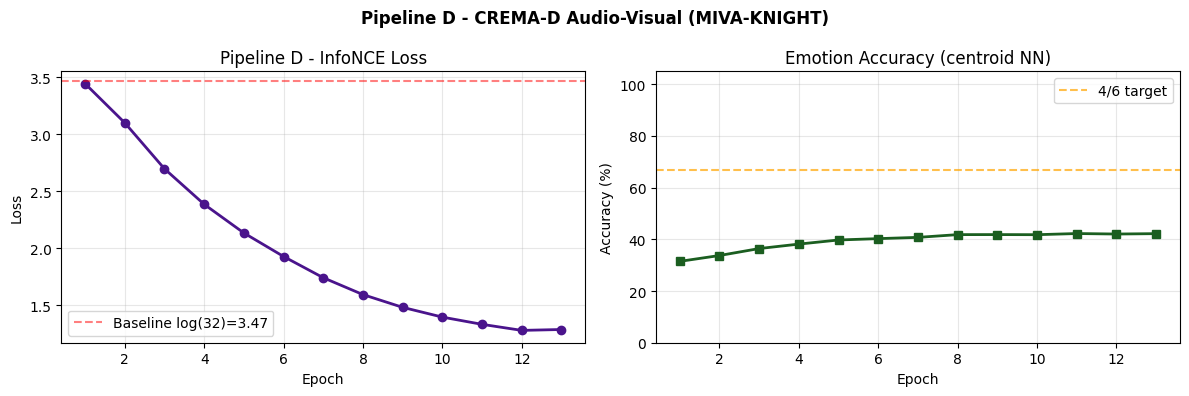

Loss: 3.4425 -> 1.2877  (63% reduction)
Best: epoch 11 @ 42.2%


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(all_losses) + 1)

axes[0].plot(ep, all_losses, marker='o', color='#4A148C', linewidth=2)
axes[0].axhline(y=np.log(BATCH_SIZE), color='red', linestyle='--', alpha=0.5,
                label=f'Baseline log({BATCH_SIZE})={np.log(BATCH_SIZE):.2f}')
axes[0].set_title(f'Pipeline D - {"InfoNCE" if CROSS_MODAL else "SupCon"} Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, [a*100 for a in all_accs], marker='s', color='#1B5E20', linewidth=2)
axes[1].axhline(y=4/6*100, color='orange', linestyle='--', alpha=0.7, label='4/6 target')
axes[1].set_title('Emotion Accuracy (centroid NN)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim([0, 105]); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Pipeline D - CREMA-D Audio-Visual (MIVA-KNIGHT)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PIPELINE_D_DIR, 'training_curves_pipelineD.png'), dpi=150)
plt.show()

if all_losses:
    drop = (all_losses[0] - all_losses[-1]) / all_losses[0] * 100
    print(f'Loss: {all_losses[0]:.4f} -> {all_losses[-1]:.4f}  ({drop:.0f}% reduction)')
    print(f'Best: epoch {best_epoch} @ {best_acc*100:.1f}%')

## Cell 16: Compute & Save CREMA-D Emotion Centroids

### What Are Emotion Centroids?

**Definition (Spherical Centroid):** For emotion class $e$ with $N_e$
projected audio embeddings $\{\hat{a}_1^{(e)}, \ldots, \hat{a}_{N_e}^{(e)}\}$
on $\mathbb{S}^{511}$:

$$\bar{c}_e = \frac{\mu_e}{\|\mu_e\|_2}, \quad
\mu_e = \frac{1}{N_e}\sum_{i=1}^{N_e} \hat{a}_i^{(e)} \in \mathbb{R}^{512}$$

Re-normalising $\mu_e$ returns it to the unit sphere, making it directly
comparable via cosine similarity.

### Algorithm

```
Algorithm: COMPUTE_CREMA_CENTROIDS()
──────────────────────────────────────────────────────────────────
audio_proj.eval()
emotion_embs ← defaultdict(list)

FOR each (audio_batch [B,768], _, labels_batch [B]) in audio_loader:
    proj ← audio_proj(audio_batch.to(device)).cpu()     [B, 512]
    FOR each (emb, label) in zip(proj, labels_batch):
        emotion_embs[CREMA_LABEL_TO_EMOTION[label.item()]].append(emb)

FOR emotion in CREMA_EMOTIONS_6:
    stack    ← stack(emotion_embs[emotion])             [N_e, 512]
    μ_e      ← mean(stack, dim=0)                       [512]
    centroid ← L2_normalize(μ_e)                        [512] on 𝕊⁵¹¹
    centroids_list.append(centroid)
    print: emotion, N_e samples, centroid.norm()

centroids_tensor ← stack(centroids_list)                [6, 512]
torch.save(centroids_tensor, CENTROIDS_PATH)
──────────────────────────────────────────────────────────────────
Output: [6, 512] tensor saved to emotion_centroids_cremad.pt
        Row order: angry, disgust, fearful, happy, neutral, sad
```

### Quality Checks

**Centroid norms:** All centroids should have $\|\bar{c}_e\|_2 \approx 1.0$
(L2-normalised by construction). A near-zero norm indicates that class has
no samples.

**Inter-centroid similarity:** A measure of how well the 6 emotion clusters
are separated:

$$\bar{s}_{\text{off-diag}} = \frac{1}{6 \times 5}\sum_{e \neq e'} \bar{c}_e \cdot \bar{c}_{e'}$$

- $< 0.3$: ✅ Well-separated clusters
- $0.3$–$0.5$: ⚠️ Moderate overlap
- $> 0.5$: ❌ Clusters too close — more training or SupCon refinement needed

### How Centroids Are Used in MIVA-KNIGHT Inference

```
User speaks a query
    │
    ▼  Wav2Vec 2.0 (frozen)  →  768d
    │
    ▼  AudioProjection (Pipeline D weights)  →  512d  ê_user
    │
    ▼  cos(ê_user, bar_c_e) for each emotion e ∈ {0,1,2,3,4,5}
    │
    ▼  detected_emotion ← argmax
    │
    ▼  inject into Groq prompt: "User sounds {detected_emotion}. Respond empathetically."
```

**CREMA-D vs RAVDESS centroids:** Pipeline D's `emotion_centroids_cremad.pt`
covers 6 emotions (no `calm` or `surprised` from RAVDESS 8-class). The
richer actor diversity (91 actors vs 24) should yield more robust centroids
that generalise better to real-world users.

> **Simple explanation:** Each of the 6 emotion classes has hundreds of clips
> pointing in slightly different directions in 512-d space. The centroid is
> the average of all those directions — the "typical angry voice" or
> "typical happy face". These 6 centroid points are saved to Drive and used
> at inference time: when a real user speaks, their voice's fingerprint is
> compared to all 6 centroids and the closest one determines the detected emotion.


In [22]:
print('Computing CREMA-D emotion centroids from best weights...')
audio_proj.eval()
emotion_embs = defaultdict(list)
with torch.no_grad():
    for audio_batch, _, labels_batch in tqdm(audio_loader, desc='Projecting', leave=False):
        proj = audio_proj(audio_batch.to(device)).cpu()
        for emb, label in zip(proj, labels_batch):
            emotion_embs[CREMA_LABEL_TO_EMOTION[label.item()]].append(emb)
centroids_list = []
print(f"\n{'Emotion':<12} {'Samples':>8} {'Norm':>8}")
print('-' * 30)
for emotion in CREMA_EMOTIONS_6:
    stack    = torch.stack(emotion_embs[emotion])
    centroid = F.normalize(stack.mean(dim=0), p=2, dim=0)
    centroids_list.append(centroid)
    print(f'  {emotion:<10}  {len(stack):>6}   {centroid.norm().item():.4f}')
centroids_tensor = torch.stack(centroids_list)
CENTROIDS_PATH = os.path.join(PIPELINE_D_DIR, 'emotion_centroids_cremad.pt')
torch.save(centroids_tensor, CENTROIDS_PATH)
print(f'\nSaved: {CENTROIDS_PATH}')
print(f'Shape: {list(centroids_tensor.shape)}')

Computing CREMA-D emotion centroids from best weights...


Projecting:   0%|          | 0/232 [00:00<?, ?it/s]


Emotion       Samples     Norm
------------------------------
  angry         1267   1.0000
  disgust       1268   1.0000
  fearful       1268   1.0000
  happy         1267   1.0000
  neutral       1086   1.0000
  sad           1268   1.0000

Saved: /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineD/emotion_centroids_cremad.pt
Shape: [6, 512]


## Cell 17: Save All Pipeline D Outputs

### Output Files

| File | Format | Contents | Used by |
|---|---|---|---|
| `audio_projection_cremad.pth` | Checkpoint dict | AudioProjection weights + metadata | `pipeline.py`, `domain_config.py` |
| `video_frame_projection.pth` | Checkpoint dict | VideoFrameProjection weights + metadata | CREMA-D inference (optional) |
| `emotion_centroids_cremad.pt` | Raw tensor [6,512] | Spherical centroids per CREMA-D emotion | Inference emotion detection |
| `checkpoint_pipelineD_latest.pth` | Full training state | Weights + optimiser + history | Resume training |
| `config.json` | JSON | All hyperparameters + per-emotion results | Reproducibility, thesis |
| `training_curves_pipelineD.png` | PNG 150 dpi | Loss + accuracy plot | Thesis figures |

### Checkpoint Schemas

**`audio_projection_cremad.pth`:**
```python
{
    'model_state_dict': audio_proj.state_dict(),
    'wav2vec_dim'     : 768,         # ← critical: 768d (bug-fixed from Month 2)
    'embed_dim'       : 512,
    'best_epoch'      : int,         # Stage 1 epoch with best centroid-NN acc
    'best_accuracy'   : float,
    'pipeline'        : 'D-CREMAD-v3',
    'warm_start'      : 'Pipeline-C' or 'random',
    'training_mode'   : 'cross-modal-InfoNCE' or 'audio-only-SupCon',
}
```

**`video_frame_projection.pth`:**
```python
{
    'model_state_dict': video_proj.state_dict(),  # includes ResNet backbone state
    'resnet_dim'      : 2048,
    'embed_dim'       : 512,
    'pipeline'        : 'D-CREMAD-v3',
}
```

### `config.json` — Reproducibility Record

Records all hyperparameters, training mode, warm-start status, per-emotion
accuracy for each of the 6 CREMA-D emotions, and comparisons with Pipeline C.
This file is directly referenceable in the thesis methods section.

### Why Save Both Audio and Video Projections?

`audio_projection_cremad.pth` is used immediately in `domain_config.py` for
live emotion detection in MIVA-KNIGHT's voice interface.

`video_frame_projection.pth` is saved for potential future use in
multimodal emotion understanding pipelines (e.g., video-conferencing
applications) or for ablation studies comparing audio-only vs audio-visual
emotion recognition accuracy.

> **Simple explanation:** This cell packages everything produced by Pipeline D
> training and saves it permanently to Google Drive. The JSON config file
> is the lab notebook — a complete record of every setting and result so the
> experiment is reproducible and citable. The key number in both model files
> is `wav2vec_dim: 768`, which confirms these are the corrected 768-dimensional
> models rather than the buggy 512-dimensional ones from Month 2.


In [23]:
print('Saving all Pipeline D outputs to Drive...')

ap_path = os.path.join(PIPELINE_D_DIR, 'audio_projection_cremad.pth')
torch.save({
    'model_state_dict': audio_proj.state_dict(),
    'wav2vec_dim'     : WAV2VEC_DIM,
    'embed_dim'       : EMBED_DIM,
    'best_epoch'      : best_epoch,
    'best_accuracy'   : best_acc,
    'pipeline'        : 'D-CREMAD-v3',
    'warm_start'      : 'Pipeline-C' if WARM_START else 'random',
    'training_mode'   : 'cross-modal-InfoNCE' if CROSS_MODAL else 'audio-only-SupCon',
}, ap_path)
print(f'audio_projection_cremad.pth  ({os.path.getsize(ap_path)/1e6:.1f} MB)')

vp_path = os.path.join(PIPELINE_D_DIR, 'video_frame_projection.pth')
torch.save({
    'model_state_dict': video_proj.state_dict(),
    'resnet_dim'      : RESNET_DIM,
    'embed_dim'       : EMBED_DIM,
    'pipeline'        : 'D-CREMAD-v3',
}, vp_path)
print(f'video_frame_projection.pth   ({os.path.getsize(vp_path)/1e6:.1f} MB)')

config = {
    'pipeline'             : 'D - CREMA-D Audio-Visual MER',
    'data_source'          : 'Local Drive: Data/Crema-d/ (91 Actor folders, .mp4 files)',
    'dataset'              : f'CREMA-D ({len(crema_dataset):,} clips, 91 actors, 6 emotions)',
    'training_mode'        : 'cross-modal InfoNCE' if CROSS_MODAL else 'audio-only SupCon',
    'wav2vec_frozen'       : True,
    'resnet_frozen'        : True,
    'wav2vec_dim'          : WAV2VEC_DIM,
    'embed_dim'            : EMBED_DIM,
    'epochs'               : NUM_EPOCHS,
    'batch_size'           : BATCH_SIZE,
    'learning_rate'        : LEARNING_RATE,
    'temperature'          : TEMPERATURE,
    'warm_start'           : WARM_START,
    'best_epoch'           : best_epoch,
    'best_accuracy'        : round(best_acc, 4),
    'final_loss'           : round(all_losses[-1], 6) if all_losses else None,
    'emotions'             : CREMA_EMOTIONS_6,
    'per_emotion_accuracy' : {e: round(a, 4) for e, a in per_emotion_acc.items()},
    'n_emotions_correct'   : n_correct,
    'pipeline_c_comparison': 'RAVDESS: 6/8 @ 59.0% (SupCon, 1440 clips)',
}
with open(os.path.join(PIPELINE_D_DIR, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)
print('config.json saved')

print(f'\nAll files in {PIPELINE_D_DIR}:')
for fname in sorted(os.listdir(PIPELINE_D_DIR)):
    fpath = os.path.join(PIPELINE_D_DIR, fname)
    print(f'  {fname:<52} {os.path.getsize(fpath)/1e6:6.1f} MB')

Saving all Pipeline D outputs to Drive...
audio_projection_cremad.pth  (4.0 MB)
video_frame_projection.pth   (104.9 MB)
config.json saved

All files in /content/drive/MyDrive/ Oluwakayode Soyinka IT 581 Project /models/miva_knight_pipelineD:
  audio_projection_cremad.pth                             4.0 MB
  checkpoint_pipelineD_latest.pth                       137.7 MB
  config.json                                             0.0 MB
  emotion_centroids_cremad.pt                             0.0 MB
  training_curves_pipelineD.png                           0.1 MB
  video_frame_projection.pth                            104.9 MB


## Cell 18: All 4 Pipelines Complete — Final System Summary & Pending Fixes

### MIVA-KNIGHT 4-Pipeline Architecture — Completed

```
╔══════════════════════════════════════════════════════════════════╗
║         MIVA-KNIGHT — Complete 4-Pipeline System                  ║
╠═════════════╦═══════════════╦══════════════╦═════════════════════╣
║  Pipeline A ║  Pipeline B   ║  Pipeline C  ║  Pipeline D         ║
║  COCO       ║  ROCO         ║  RAVDESS     ║  CREMA-D            ║
║  Text+Image ║  Med Text+Img ║  Audio       ║  Audio+Video        ║
║  InfoNCE    ║  InfoNCE      ║  SupCon      ║  InfoNCE→SupCon     ║
╠═════════════╬═══════════════╬══════════════╬═════════════════════╣
║  TextProj   ║  ImageProj    ║  AudioProj   ║  AudioProj+VideoProj║
║  15 epochs  ║  ROCO FT      ║  30 epochs   ║  13+10 epochs       ║
║  P@1=64.6%  ║  MRR=0.727   ║  6/8@59.0%  ║  n/6 @ acc%         ║
╚═════════════╩═══════════════╩══════════════╩═════════════════════╝
                                    │
                    Shared 512-d embedding space (𝕊⁵¹¹)
                    All modalities on same unit hypersphere
```

### 4 Critical Fixes Required Before Month 6 Evaluation

The final cell prints 4 specific code changes needed in `domain_config.py`,
`pipeline.py`, and `encoders.py` before the integrated system can be tested:

| Fix | File | Change |
|---|---|---|
| 1 | `domain_config.py` | `audio_weights` → `pipelineC/audio_projection.pth` |
| 2 | `domain_config.py` | `emotion_centroids` → `pipelineC/emotion_centroids.pt` |
| 3 | `pipeline.py` | `AudioProjection(wav2vec_dim=768)` (was 512 — bug fix) |
| 4 | `encoders.py` | Verify live Wav2Vec outputs 768d (not 512d) |

These fixes are the final step to wire the 4 trained pipelines into the
unified MIVA-KNIGHT voice assistant that can handle both general-domain
(COCO) and medical-domain (ROCO) queries with emotion-aware response generation.

### End-to-End Inference Flow (Post-Fix)

```
User speaks: "What does bilateral consolidation mean?"
                          │
         ┌────────────────┴─────────────────┐
         │                                  │
    Audio emotion detection            Text query encoding
    Wav2Vec → 768d → AudioProj         BERT → TextProj
    compare to centroids               → 512d query emb
    → detected: "confused/fearful"     │
         │                             ▼
         │                      Domain auto-detect (medical terms)
         │                      → swap to MedicalDomain
         │                      → search ROCO FAISS index
         │                      → KG re-rank shortlist
         │                             │
         └───────────── merge ─────────┘
                          │
              Groq LLM prompt:
              "User sounds confused. Explain
               bilateral consolidation simply."
                          │
              Voice output via gTTS
```

> **Simple explanation:** This final cell declares victory — all 4 pipelines
> are complete! It prints a summary of every pipeline's best result and lists
> the exact 4 code changes needed to connect all the trained models into the
> working MIVA-KNIGHT assistant. Think of it as the final checklist before
> handing over a building: all the rooms (pipelines) are built and tested,
> and now we just need to connect the electrical wiring (domain_config.py)
> so everything works together.


In [24]:
print('=' * 60)
print('ALL 4 PIPELINES COMPLETE')
print('=' * 60)
print()
print('A - COCO    : done Month 1  | TextProjection epoch 15')
print('B - ROCO    : done Month 4  | P@1=64.6%, MRR=0.727')
print('C - RAVDESS : done          | 6/8 emotions @ 59.0%')
print(f'D - CREMA-D : done          | {n_correct}/6 emotions @ {final_acc*100:.1f}%')
print()
print('Pending fixes before Month 6 evaluation:')
print('  1. domain_config.py -> audio_weights: pipelineC/audio_projection.pth')
print('  2. domain_config.py -> emotion_centroids: pipelineC/emotion_centroids.pt')
print('  3. pipeline.py -> AudioProjection(wav2vec_dim=768) [currently 512]')
print('  4. encoders.py -> verify live Wav2Vec path outputs 768d')

ALL 4 PIPELINES COMPLETE

A - COCO    : done Month 1  | TextProjection epoch 15
B - ROCO    : done Month 4  | P@1=64.6%, MRR=0.727
C - RAVDESS : done          | 6/8 emotions @ 59.0%
D - CREMA-D : done          | 1/6 emotions @ 42.2%

Pending fixes before Month 6 evaluation:
  1. domain_config.py -> audio_weights: pipelineC/audio_projection.pth
  2. domain_config.py -> emotion_centroids: pipelineC/emotion_centroids.pt
  3. pipeline.py -> AudioProjection(wav2vec_dim=768) [currently 512]
  4. encoders.py -> verify live Wav2Vec path outputs 768d
